# Data Processing

## 1. Konfigurasi

In [1]:
import datetime
import re
from pathlib import Path
from typing import Optional, Union

import holidays
import numpy as np
import pandas as pd


def find_base_dir(start=None) -> Path:
    """Cari root repo — folder pertama ke atas yang berisi `dataset/csv/`."""
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "dataset" / "csv").is_dir():
            return candidate
    raise RuntimeError(f"Root repo tidak ditemukan dari {start}")


BASE_DIR = find_base_dir()

RAW_DATA_FILE = str(BASE_DIR / "dataset/csv/dataset.csv")
OUTLETS_FILE = str(BASE_DIR / "dataset/outlets.csv")
OVERRIDES_FILE = str(BASE_DIR / "dataset/outlet_name_overrides.csv")
REGION_MAPPING_FILE = str(BASE_DIR / "dataset/outlet_mapping.csv")
CLOSURES_FILE = str(BASE_DIR / "dataset/outlet_closures.csv")
MODEL_READY_DIR = str(BASE_DIR / "dataset/model_ready")

DATE_FORMAT = "%d %b %Y"


TEST_START = pd.Timestamp("2025-12-01")


MIN_HISTORY_DAYS = 60


PAIR_COLS = ["Kode Barang", "Nama Cabang"]


CARRY_COLS = ["Kategori Barang", "Nama Barang", "Satuan"]


SEGMENT_COL = "segment_id"


SEGMENT_COLS = PAIR_COLS + [SEGMENT_COL]


BRANCH_COL = "Nama Cabang"


TARGET_HORIZONS = range(1, 8)


LAG_DAYS = [1, 2, 3, 7, 14, 21, 28]


ROLLING_WINDOWS = [7, 14, 28]


MIN_GAP_WARN_DAYS = 14


print(f"BASE_DIR      = {BASE_DIR}")
print(f"RAW_DATA_FILE = {RAW_DATA_FILE}")
print(f"TEST_START    = {TEST_START.date()}  (test set Desember 2025 terkunci)")
for path in [RAW_DATA_FILE, OUTLETS_FILE, OVERRIDES_FILE, REGION_MAPPING_FILE, CLOSURES_FILE]:
    print(f"  {'ok    ' if Path(path).exists() else 'HILANG'} {Path(path).relative_to(BASE_DIR)}")

BASE_DIR      = /Users/ramapdp/Project/Personal/forecast-scm
RAW_DATA_FILE = /Users/ramapdp/Project/Personal/forecast-scm/dataset/csv/dataset.csv
TEST_START    = 2025-12-01  (test set Desember 2025 terkunci)
  ok     dataset/csv/dataset.csv
  ok     dataset/outlets.csv
  ok     dataset/outlet_name_overrides.csv
  ok     dataset/outlet_mapping.csv
  ok     dataset/outlet_closures.csv


## 2. Normalisasi kode & nama item

In [2]:
XXX_PREFIX_RE = re.compile(r"^xxx\.\s*", re.IGNORECASE)


SEPARATOR_RE = re.compile(r"(?<=[A-Za-z])\.(?=\d)")


TRAILING_PAREN_RE = re.compile(r"\s*\([^()]*\)\s*$")


WHITESPACE_RE = re.compile(r"(?<=\d)(?=[a-z])|(\s+)")


def strip_xxx_prefix(value: str) -> str:
    """Buang prefix 'xxx.' (case-insensitive) dari kode barang.

    Prefix ini muncul di data sumber lama sebagai penanda sementara dan tidak
    membawa makna bisnis — menghapusnya menyatukan kode yang sebenarnya sama.
    """
    return XXX_PREFIX_RE.sub("", value)


def unify_separator(code: str) -> str:
    """Ganti titik antara huruf dan angka dengan strip (mis. 'FGS.00001' → 'FGS-00001').

    Data sumber menggunakan campuran titik dan strip sebagai separator pada
    kode barang. Penyatuan ke strip memungkinkan kode yang sama dikenali sebagai
    kunci yang identik tanpa mengubah makna.
    """
    return SEPARATOR_RE.sub("-", code)


def normalize_name_for_comparison(name: str) -> str:
    name = strip_xxx_prefix(name)
    name = TRAILING_PAREN_RE.sub("", name)
    name = WHITESPACE_RE.sub(" ", name).strip()
    return name


def resolve_conditional_normalization(
    df: pd.DataFrame, transform, code_col: str = "Kode Barang", name_col: str = "Nama Barang"
) -> dict[str, str]:
    """Terapkan transform pada kode barang, tapi hanya jika semua kode yang tergabung
    setelah transform punya nama barang yang identik (setelah normalisasi nama).

    Ini mencegah dua item berbeda secara fisik (mis. dua SKU dengan nama berbeda)
    digabungkan hanya karena kode mereka mirip setelah transformasi. Jika ada
    konflik nama, kode asli dipertahankan tanpa perubahan.
    """
    names_by_raw = df.groupby(code_col)[name_col].apply(
        lambda s: {normalize_name_for_comparison(n) for n in s}
    )
    transformed = {raw: transform(raw) for raw in names_by_raw.index}
    groups: dict[str, list[str]] = {}
    for raw, t in transformed.items():
        groups.setdefault(t, []).append(raw)

    mapping: dict[str, str] = {}
    for t, raws in groups.items():
        all_names: set[str] = set()
        for raw in raws:
            all_names |= names_by_raw[raw]
        if len(all_names) == 1:
            for raw in raws:
                mapping[raw] = t
        else:
            for raw in raws:
                mapping[raw] = raw
    return mapping


def build_normalized_code_map(
    df: pd.DataFrame, code_col: str = "Kode Barang", name_col: str = "Nama Barang"
) -> dict[str, str]:
    """Bangun peta kode_asli → kode_normal dalam dua pass berurutan.

    Pass 1: strip prefix 'xxx.' (kondisional — lihat resolve_conditional_normalization).
    Pass 2: ganti titik-sebagai-separator dengan strip, diterapkan pada hasil pass 1.

    Dua pass terpisah diperlukan karena transformasi pertama bisa mengubah
    konteks untuk transformasi kedua: kode yang tadinya identik setelah strip-xxx
    mungkin masih berbeda titik/strip-nya.
    """
    pass1 = resolve_conditional_normalization(df, strip_xxx_prefix, code_col, name_col)

    df_pass1 = df.copy()
    df_pass1[code_col] = df_pass1[code_col].map(pass1)

    pass2 = resolve_conditional_normalization(df_pass1, unify_separator, code_col, name_col)

    return {raw: pass2[pass1[raw]] for raw in pass1}


def apply_item_normalization(df: pd.DataFrame) -> pd.DataFrame:
    """Terapkan peta normalisasi kode ke seluruh DataFrame, mengganti kolom Kode Barang."""
    code_map = build_normalized_code_map(df)
    result = df.copy()
    result["Kode Barang"] = result["Kode Barang"].map(code_map)
    return result


def canonicalize_item_names(
    df: pd.DataFrame, code_col: str = "Kode Barang", name_col: str = "Nama Barang"
) -> pd.DataFrame:
    """Seragamkan Nama Barang tiap kode ke satu nama kanonik (nama tanpa prefix 'xxx.').

    Baris dengan prefix 'xxx.' dianggap nama sementara; baris bersih dijadikan
    referensi. Jika semua baris suatu kode masih pakai prefix, nama aslinya dipertahankan.
    """
    result = df.copy()
    is_clean = result[name_col].map(strip_xxx_prefix) == result[name_col]
    canonical = result.loc[is_clean].groupby(code_col)[name_col].first()
    result[name_col] = result[code_col].map(canonical).fillna(result[name_col])
    return result

## 3. Kanonikalisasi kategori barang

In [3]:
CATEGORY_SYNONYMS: dict[str, str] = {
    "Minuman": "Minuman - FG",
    "Snack": "Snack (FG)",
}


_ADMINISTRATIVE_WIP2_RELABEL = [
    "FGS-00001",  # Ayam Kebuli (0.9)
    "FGS-00002",  # Kambing Kebuli
    "FGS-00003",  # Iga Sapi Kebuli
    "FGS-00004",  # Nasi Kebuli
    "FGS-00005",  # Sambal - FG
    "FGS-00012",  # Samosa Beef Original (RM)
    "FGS-00013",  # Samosa Beef Spicy (RM)
    "FGS-00018",  # Kambing Kebuli Aqiqah Betina - FG
    "FGS-00049",  # Iga Dino - FG
    "FGS-00053",  # Ayam Kebuli (0.6)
]


EXPLICIT_CATEGORY_OVERRIDES: dict[str, str] = {
    "FGS-00014": "Minuman - FG",
    **{code: "Barang Jadi (FG)" for code in _ADMINISTRATIVE_WIP2_RELABEL},
}


def canonicalize_item_categories(
    df: pd.DataFrame,
    code_col: str = "Kode Barang",
    category_col: str = "Kategori Barang",
    date_col: str = "Tanggal",
) -> pd.DataFrame:
    """Seragamkan kategori per SKU menggunakan sinonim dan override eksplisit.

    Dua langkah:
    1. Sinonim (CATEGORY_SYNONYMS): satukan varian penamaan yang identik secara
       bisnis (mis. 'Minuman' → 'Minuman - FG') hanya jika SKU itu memang
       hanya punya satu kategori setelah penyatuan.
    2. Override eksplisit (EXPLICIT_CATEGORY_OVERRIDES): tulis ulang kategori
       untuk SKU tertentu yang sudah dikonfirmasi pemilik data, terlepas dari
       apa yang tertulis di sumber.
    """
    result = df.copy()
    normalized = result[category_col].replace(CATEGORY_SYNONYMS)

    # Only collapse a SKU's history to one category when every recorded
    # category is the same after synonym normalization (e.g. Minuman /
    # Minuman - FG). Genuinely different categories (e.g. WIP-2 vs Barang
    # Jadi (FG)) are left time-varying, as recorded.
    single_category = normalized.groupby(result[code_col]).transform("nunique") == 1
    result.loc[single_category, category_col] = normalized.loc[single_category]

    override_mask = result[code_col].isin(EXPLICIT_CATEGORY_OVERRIDES)
    result.loc[override_mask, category_col] = result.loc[override_mask, code_col].map(
        EXPLICIT_CATEGORY_OVERRIDES
    )

    return result

## 4. Exclude cabang/item & konversi satuan

In [4]:
EXCLUDED_BRANCHES = {"Kebab Saudagar - Kutabumi"}


def exclude_branches(
    df: pd.DataFrame, branches: set[str] = EXCLUDED_BRANCHES, branch_col: str = "Nama Cabang"
) -> pd.DataFrame:
    """Buang semua baris dari cabang yang ada di daftar EXCLUDED_BRANCHES."""
    return df[~df[branch_col].isin(branches)].reset_index(drop=True)


GRAM_TO_PORSI_FACTORS: dict[str, int] = {
    "xxx.FGS.00070": 40,  # Santan Cendol
    "xxx.FGS.00071": 30,  # Gula Cendol
}


def convert_gram_items_to_porsi(
    df: pd.DataFrame,
    factors: dict[str, int] = GRAM_TO_PORSI_FACTORS,
    code_col: str = "Kode Barang",
    unit_col: str = "Satuan",
    qty_col: str = "Kuantitas",
) -> pd.DataFrame:
    """Konversi kuantitas item tertentu dari Gram ke Porsi menggunakan faktor konversi.

    Item seperti Santan/Gula Cendol dicatat dalam gram di sumber, tetapi
    secara operasional lebih bermakna dalam porsi. Konversi dilakukan hanya
    pada baris dengan satuan 'Gr' supaya baris yang sudah benar tidak tersentuh.
    """
    result = df.copy()
    result[qty_col] = result[qty_col].astype(float)
    for code, factor in factors.items():
        mask = (result[code_col] == code) & (result[unit_col] == "Gr")
        result.loc[mask, qty_col] = result.loc[mask, qty_col] / factor
        result.loc[mask, unit_col] = "Porsi"
    return result


EXCLUDED_ITEMS = {"xxx.FGS.00066", "xxx.FGS.00067", "xxx.FGS.00068", "xxx.FGS.00069"}


def exclude_items(
    df: pd.DataFrame, items: set[str] = EXCLUDED_ITEMS, code_col: str = "Kode Barang"
) -> pd.DataFrame:
    """Buang semua baris dari item yang ada di daftar EXCLUDED_ITEMS."""
    return df[~df[code_col].isin(items)].reset_index(drop=True)


EXPLICIT_ITEM_RENAMES: dict[str, tuple[str, str]] = {}


def apply_item_renames(
    df: pd.DataFrame,
    renames: dict[str, tuple[str, str]] = EXPLICIT_ITEM_RENAMES,
    code_col: str = "Kode Barang",
    name_col: str = "Nama Barang",
) -> pd.DataFrame:
    """Ganti kode dan nama item tertentu menggunakan peta rename eksplisit.

    Berbeda dari normalisasi otomatis: rename eksplisit dipakai ketika kode
    lama dan baru tidak bisa disatukan oleh aturan regex (mis. penggantian
    kode total oleh pemilik data).
    """
    result = df.copy()
    matched = result[code_col].isin(renames)
    raw_codes = result.loc[matched, code_col]
    result.loc[matched, code_col] = raw_codes.map(lambda c: renames[c][0])
    result.loc[matched, name_col] = raw_codes.map(lambda c: renames[c][1])
    return result

## 5. Agregasi harian & pipeline normalisasi

In [5]:
AGG_SPEC = {"Kuantitas": "sum", "Kategori Barang": "first", "Nama Barang": "first", "Satuan": "first"}


def reaggregate_daily(df: pd.DataFrame) -> pd.DataFrame:
    """Agregasi ulang ke level harian per (item, cabang) setelah normalisasi kode.

    Normalisasi kode bisa menggabungkan beberapa kode yang tadinya berbeda
    menjadi satu. Tanpa agregasi ulang ini, hasil penggabungan akan punya
    banyak baris duplikat per (item, cabang, tanggal).
    """
    return df.groupby(["Kode Barang", "Tanggal", "Nama Cabang"], as_index=False).agg(AGG_SPEC)


def load_and_normalize(path: str = RAW_DATA_FILE) -> pd.DataFrame:
    """Muat dataset CSV mentah lalu jalankan seluruh pipeline normalisasi item.

    Urutan langkah dipentingkan:
    1. Exclude cabang & rename eksplisit — sebelum normalisasi kode supaya
       mapping tidak mencampur item dari cabang yang akan dibuang.
    2. Konversi unit & exclude item — sebelum normalisasi kode.
    3. Normalisasi kode (xxx-prefix + separator) — menyatukan kode yang sama.
    4. Kanonikalisasi nama & kategori — setelah kode final diketahui.
    5. Re-agregasi harian — setelah normalisasi kode bisa menggabungkan baris.
    """
    df = pd.read_csv(path, sep=";", encoding="utf-8-sig")
    df["Tanggal"] = pd.to_datetime(df["Tanggal"], format=DATE_FORMAT)
    df = exclude_branches(df)
    df = apply_item_renames(df)
    df = convert_gram_items_to_porsi(df)
    df = exclude_items(df)
    df = apply_item_normalization(df)
    df = canonicalize_item_names(df)
    df = canonicalize_item_categories(df)
    df = reaggregate_daily(df)
    return df

## 6. Jalankan load & normalize

In [6]:
normalized = load_and_normalize()

print(normalized.shape)
normalized.head()

(692752, 7)


,Kode Barang,Tanggal,Nama Cabang,Kuantitas,Kategori Barang,Nama Barang,Satuan
0,FGS-00001,2024-01-01,KY001 - Kebuli Yaman Kutabumi (Pusat),235.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
1,FGS-00001,2024-01-01,KY002 - Kebuli Yaman Cilegon,168.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
2,FGS-00001,2024-01-01,KY003 - Kebuli Yaman Serang,84.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
3,FGS-00001,2024-01-01,KY004 - Kebuli Yaman Depok Sawangan,60.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
4,FGS-00001,2024-01-01,KY005 - Kebuli Yaman Pandeglang,121.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong


## 7. Cek terbuka — item ber-prefix `xxx.`

In [7]:
# Blocker #2 (belum ada keputusan). Menampilkan baris mentah — sebelum exclude/rename — untuk
# kode yang ditangani EXCLUDED_ITEMS/EXPLICIT_ITEM_RENAMES, plus satu pembanding
# (xxx.FGS.00068) yang auto-merge tanpa aturan eksplisit karena namanya sudah identik dengan
# versi non-prefix. Keputusan exclude/rename yang berlaku sekarang adalah asumsi penulis kode,
# belum dikonfirmasi ke data owner.
raw = pd.read_csv(RAW_DATA_FILE, sep=";", encoding="utf-8-sig")
raw["Tanggal"] = pd.to_datetime(raw["Tanggal"], format=DATE_FORMAT)

print("--- Saat ini DI-DROP oleh EXCLUDED_ITEMS ---")
excluded_rows = raw[raw["Kode Barang"].isin(EXCLUDED_ITEMS)]
display(excluded_rows.groupby(["Kode Barang", "Nama Barang"]).agg(
    n_baris=("Kuantitas", "size"), min_qty=("Kuantitas", "min"),
    max_qty=("Kuantitas", "max"), total_qty=("Kuantitas", "sum"),
))
display(excluded_rows.sort_values("Kuantitas", ascending=False).head(3))

print("\n--- Saat ini DI-RENAME oleh EXPLICIT_ITEM_RENAMES (xxx.FGS.00067 -> FGS-00068) ---")
renamed_rows = raw[raw["Kode Barang"] == "xxx.FGS.00067"]
display(renamed_rows.sort_values("Kuantitas", ascending=False).head(3))

print("--- Pembanding: xxx.FGS.00068 (auto-merge ke FGS-00068 tanpa aturan eksplisit, nama sudah identik) ---")
print("Catatan: xxx.FGS.00067 bernama 'Ayam Crispy Original - FG' tapi di-rename manual ke SKU")
print("'FGS-00068 / Ayam Crispy Spicy - FG' -- dua rasa berbeda digabung jadi satu SKU.")
print("Ini keputusan manual yang belum eksplisit dikonfirmasi ke data owner.")
comparison_rows = raw[raw["Kode Barang"] == "xxx.FGS.00068"]
display(comparison_rows.sort_values("Kuantitas", ascending=False).head(3))

--- Saat ini DI-DROP oleh EXCLUDED_ITEMS ---


,,n_baris,min_qty,max_qty,total_qty
Kode Barang,Nama Barang,,,,
xxx.FGS.00066,xxx.Nasi Putih,21,200.0,1600.0,9200.0
xxx.FGS.00067,xxx.Ayam Crispy Original - FG,303,1.0,11.0,753.0
xxx.FGS.00068,xxx.Ayam Crispy Spicy - FG,276,1.0,12.0,656.0
xxx.FGS.00069,xxx.Cendol Pandan - FG,74,125.0,5250.0,55500.0


,Tanggal,Kategori Barang,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas
320563,2025-01-25,Barang Jadi (FG),xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Gr,5250.0
322331,2025-01-27,Barang Jadi (FG),xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Gr,2625.0
320024,2025-01-25,Barang Jadi (FG),xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Gr,2500.0



--- Saat ini DI-RENAME oleh EXPLICIT_ITEM_RENAMES (xxx.FGS.00067 -> FGS-00068) ---


,Tanggal,Kategori Barang,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas
523644,2025-07-31,Barang Jadi (FG),xxx.FGS.00067,xxx.Ayam Crispy Original - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Potong,11.0
328409,2025-02-02,Barang Jadi (FG),xxx.FGS.00067,xxx.Ayam Crispy Original - FG,KY041 - Kebuli Yaman Sepatan,Potong,10.0
348872,2025-02-23,Barang Jadi (FG),xxx.FGS.00067,xxx.Ayam Crispy Original - FG,KY041 - Kebuli Yaman Sepatan,Potong,10.0


--- Pembanding: xxx.FGS.00068 (auto-merge ke FGS-00068 tanpa aturan eksplisit, nama sudah identik) ---
Catatan: xxx.FGS.00067 bernama 'Ayam Crispy Original - FG' tapi di-rename manual ke SKU
'FGS-00068 / Ayam Crispy Spicy - FG' -- dua rasa berbeda digabung jadi satu SKU.
Ini keputusan manual yang belum eksplisit dikonfirmasi ke data owner.


,Tanggal,Kategori Barang,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas
311333,2025-01-15,Barang Jadi (FG),xxx.FGS.00068,xxx.Ayam Crispy Spicy - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Potong,12.0
363789,2025-03-09,Barang Jadi (FG),xxx.FGS.00068,xxx.Ayam Crispy Spicy - FG,KY042 - Kebuli Yaman Batavia,Potong,11.0
524579,2025-07-31,Barang Jadi (FG),xxx.FGS.00068,xxx.Ayam Crispy Spicy - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Potong,9.0


## 8. Cek terbuka — outlier Kuantitas ekstrem

In [8]:
# Top-20 baris Kuantitas tertinggi di dataset.csv mentah. Kolom is_xxx_prefix menandai baris
# yang beririsan dengan keputusan xxx. di atas — banyak outlier ekstrem justru berasal dari item
# yang statusnya belum jelas, dan beberapa dalam satuan Gr (gram) bukan Potong/Porsi, jadi angka
# besar tidak otomatis berarti anomali kuantitas fisik.
raw["is_xxx_prefix"] = raw["Kode Barang"].str.startswith("xxx.", na=False)

cols = ["Tanggal", "Kode Barang", "Nama Barang", "Nama Cabang", "Kategori Barang", "Satuan", "Kuantitas", "is_xxx_prefix"]
top20_outliers = raw.sort_values("Kuantitas", ascending=False).head(20)[cols]

print(f"{top20_outliers['is_xxx_prefix'].sum()} dari 20 outlier teratas adalah item ber-prefix xxx.")
top20_outliers

13 dari 20 outlier teratas adalah item ber-prefix xxx.


,Tanggal,Kode Barang,Nama Barang,Nama Cabang,Kategori Barang,Satuan,Kuantitas,is_xxx_prefix
320563,2025-01-25,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,5250.0,True
322331,2025-01-27,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2625.0,True
320024,2025-01-25,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2500.0,True
321740,2025-01-26,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY042 - Kebuli Yaman Batavia,Barang Jadi (FG),Gr,2250.0,True
325166,2025-01-30,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,2000.0,True
325209,2025-01-30,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2000.0,True
321466,2025-01-26,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2000.0,True
320323,2025-01-25,xxx.FGS.00070,xxx.Santan Cendol - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,1680.0,True
328643,2025-02-02,xxx.FGS.00066,xxx.Nasi Putih,KY041 - Kebuli Yaman Sepatan,Barang Jadi (FG),Gr,1600.0,True
331949,2025-02-06,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,1500.0,True


## 9. Cek terbuka — SKU tercatat di lebih dari satu kategori

In [9]:
# Blocker #5 (belum ada keputusan). reaggregate_daily memakai Kategori Barang: "first", yang
# diam-diam memilih kategori pertama kalau satu SKU pernah tercatat di lebih dari satu kategori
# (temuan eda.ipynb §2). Sel ini hanya menampilkan daftarnya sebagai pengingat, tidak mengubah
# perilaku pipeline.
categories_per_sku = normalized.groupby("Kode Barang")["Kategori Barang"].nunique()
multi_category_skus = categories_per_sku[categories_per_sku > 1]

print(f"{len(multi_category_skus)} dari {categories_per_sku.shape[0]} SKU tercatat di lebih dari satu Kategori Barang")
normalized[normalized["Kode Barang"].isin(multi_category_skus.index)].groupby("Kode Barang")["Kategori Barang"].unique()

0 dari 89 SKU tercatat di lebih dari satu Kategori Barang


Series([], Name: Kategori Barang, dtype: object)

## 10. Data outlet — loader, pencocokan & kanonikalisasi nama cabang

In [10]:
PREFIX_RE = re.compile(r"^KY\d+\s*-\s*", re.IGNORECASE)


CHANNEL_COLS = ["has_shopee", "has_gofood", "has_grabfood"]


INDONESIAN_WEEKDAYS = {
    "Senin": 0, "Selasa": 1, "Rabu": 2, "Kamis": 3,
    "Jumat": 4, "Sabtu": 5, "Minggu": 6,
}


RELOCATION_DATES: dict[str, pd.Timestamp] = {
    "KY056 - Kebuli Yaman Tigaraksa": pd.Timestamp("2024-03-01"),
    "Kebuli Yaman Cadas": pd.Timestamp("2025-10-03"),
    "Kebuli Yaman Citayam": pd.Timestamp("2025-11-07"),
    "Kebuli Yaman Bintara": pd.Timestamp("2025-11-28"),
    "Kebuli Yaman Mayor Oking": pd.Timestamp("2025-12-31"),  # lower bound
    "Kebuli Yaman Cikarang Pusat": pd.Timestamp("2025-11-30"),  # lower bound
    "Kebuli Yaman Teluk Pucung": pd.Timestamp("2025-12-31"),  # lower bound
    "Kebuli Yaman Bukit Gading Balaraja": pd.Timestamp("2025-12-31"),  # lower bound
    "Kebuli Yaman Grand Wisata Bekasi": pd.Timestamp("2025-12-31"),  # lower bound
}


LOWER_BOUND_RELOCATIONS = {
    "Kebuli Yaman Mayor Oking",
    "Kebuli Yaman Cikarang Pusat",
    "Kebuli Yaman Teluk Pucung",
    "Kebuli Yaman Bukit Gading Balaraja",
    "Kebuli Yaman Grand Wisata Bekasi",
}


OBSERVED_RELOCATION_DATES: dict[str, pd.Timestamp] = {
    branch: date
    for branch, date in RELOCATION_DATES.items()
    if branch not in LOWER_BOUND_RELOCATIONS
}


def load_outlets(path: str = OUTLETS_FILE) -> pd.DataFrame:
    """Muat daftar outlet dari CSV (data master outlet)."""
    return pd.read_csv(path, sep=";", encoding="utf-8-sig")


def load_overrides(path: str = OVERRIDES_FILE) -> pd.DataFrame:
    """Muat tabel override nama cabang → outlet (matching manual oleh data owner)."""
    return pd.read_csv(path, sep=";", encoding="utf-8-sig", dtype=str)


def load_region_mapping(path: str = REGION_MAPPING_FILE) -> pd.DataFrame:
    """Muat tabel mapping cabang → kawasan dan jadwal pengiriman."""
    return pd.read_csv(path, sep=";", encoding="utf-8-sig")


def load_closures(
    path: str = CLOSURES_FILE,
) -> dict[str, list[tuple[pd.Timestamp, Optional[pd.Timestamp]]]]:
    """Read recorded outlet closure intervals, keyed by canonical branch name.

    Each interval is [tanggal_tutup, tanggal_buka) — closed from tanggal_tutup
    inclusive through the day *before* tanggal_buka. An empty tanggal_buka
    means the outlet is still closed through the end of the data.

    Keyed on canonical `Nama Outlet` (like RELOCATION_DATES) because callers
    consume this after canonicalize_branch_names has merged old branch codes
    into their successors. Returns {} when the file is absent so the pipeline
    still runs on a checkout that has no closures recorded yet.
    """
    if not Path(path).exists():
        return {}

    raw = pd.read_csv(path, sep=";", encoding="utf-8-sig", dtype=str)
    closures: dict[str, list[tuple[pd.Timestamp, Optional[pd.Timestamp]]]] = {}

    for _, row in raw.iterrows():
        branch = str(row["Nama Outlet"]).strip()
        start = pd.to_datetime(row["tanggal_tutup"], format="%Y-%m-%d", errors="coerce")
        if pd.isna(start):
            raise ValueError(
                f"tanggal_tutup tidak valid untuk {branch!r}: {row['tanggal_tutup']!r}"
            )

        raw_end = row["tanggal_buka"]
        if pd.isna(raw_end) or not str(raw_end).strip():
            end = None
        else:
            end = pd.to_datetime(raw_end, format="%Y-%m-%d", errors="coerce")
            if pd.isna(end):
                raise ValueError(f"tanggal_buka tidak valid untuk {branch!r}: {raw_end!r}")
            if end <= start:
                raise ValueError(
                    f"tanggal_buka <= tanggal_tutup untuk {branch!r}: "
                    f"{end.date()} <= {start.date()}"
                )

        closures.setdefault(branch, []).append((start, end))

    for branch, intervals in closures.items():
        intervals.sort(key=lambda interval: interval[0])
        for (earlier_start, earlier_end), (later_start, _) in zip(intervals, intervals[1:]):
            if earlier_end is None or later_start < earlier_end:
                raise ValueError(
                    f"Interval tutup tumpang tindih untuk {branch!r}: "
                    f"{earlier_start.date()} dan {later_start.date()}"
                )

    return closures


def _strip_for_matching(nama_cabang: str) -> str:
    """Hapus prefix kode (mis. 'KY068 - ') dan tanda kurung untuk matching fuzzy ke outlets.csv."""
    stripped = PREFIX_RE.sub("", nama_cabang)
    stripped = TRAILING_PAREN_RE.sub("", stripped)
    return stripped.strip()


def match_branch_to_outlet(
    nama_cabang: str, outlets_df: pd.DataFrame, overrides_df: pd.DataFrame
) -> tuple[Optional[pd.Series], Optional[str]]:
    """Cari baris outlet yang cocok untuk nama cabang, dengan priority ke tabel override.

    Mengembalikan (outlet_row, kota_override). Jika tidak ada yang cocok, mengembalikan
    (None, None) — caller memutuskan apakah ini error atau cukup diabaikan.
    """
    override_row = overrides_df[overrides_df["Nama Cabang"] == nama_cabang]
    if not override_row.empty:
        nama_outlet = override_row.iloc[0]["Nama Outlet"]
        kota_override = override_row.iloc[0]["Kota Override"]
        outlet_row = outlets_df[outlets_df["Nama Outlet"] == nama_outlet]
        if outlet_row.empty:
            return None, None
        return outlet_row.iloc[0], (kota_override if pd.notna(kota_override) and kota_override else None)

    stripped = _strip_for_matching(nama_cabang)
    candidates = outlets_df[
        outlets_df["Nama Outlet"].str.casefold().apply(lambda name: stripped.casefold() in name)
    ]
    if len(candidates) == 1:
        return candidates.iloc[0], None
    return None, None


def normalize_kota(kota: Optional[str], kota_override: Optional[str]) -> str:
    """Pilih nilai kota yang valid: override > nilai asli > 'Unknown'."""
    if kota_override:
        return kota_override.strip()
    if kota is None or (isinstance(kota, float) and pd.isna(kota)):
        return "Unknown"
    return kota.strip()


def _to_bool(value) -> Union[bool, float]:
    if pd.isna(value):
        return float("nan")
    return value.strip().lower() == "yes"


def filter_matched_branches(
    df: pd.DataFrame,
    outlets_df: pd.DataFrame,
    overrides_df: pd.DataFrame,
    branch_col: str = "Nama Cabang",
) -> pd.DataFrame:
    """Buang baris dari cabang yang tidak ditemukan di master outlet.

    Cabang yang tidak bisa di-match tidak akan punya fitur outlet (kota, channel,
    jadwal), sehingga lebih aman untuk dibuang dari pipeline daripada diisi NaN.
    """
    branches = df[branch_col].unique()
    matched = {
        b for b in branches
        if match_branch_to_outlet(b, outlets_df, overrides_df)[0] is not None
    }
    return df[df[branch_col].isin(matched)].reset_index(drop=True)


def canonicalize_branch_names(
    df: pd.DataFrame,
    outlets_df: pd.DataFrame,
    overrides_df: pd.DataFrame,
    branch_col: str = "Nama Cabang",
) -> pd.DataFrame:
    """Ganti Nama Cabang dengan nama kanonik dari outlets.csv.

    Nama kanonik adalah 'Nama Outlet' di master outlet. Ini menyatukan kode
    lama dan baru dari cabang yang sama (mis. KY068 Kramatwatu) ke satu identitas,
    sehingga riwayat mereka tergabung dalam satu panel.
    """
    branches = df[branch_col].unique()
    canonical_names = {}
    for nama_cabang in branches:
        outlet_row, _ = match_branch_to_outlet(nama_cabang, outlets_df, overrides_df)
        canonical_names[nama_cabang] = (
            nama_cabang if outlet_row is None else outlet_row["Nama Outlet"]
        )
    result = df.copy()
    result[branch_col] = result[branch_col].map(canonical_names)
    return result


def build_outlet_features(
    branch_names: list[str], outlets_df: pd.DataFrame, overrides_df: pd.DataFrame
) -> pd.DataFrame:
    """Bangun tabel fitur outlet (kota, channel online) untuk setiap nama cabang.

    Cabang yang tidak ditemukan di master outlet tetap masuk tabel dengan
    nilai NaN — bukan dibuang — karena penapisan sudah dilakukan sebelumnya
    oleh filter_matched_branches().
    """
    rows = []
    for nama_cabang in branch_names:
        outlet_row, kota_override = match_branch_to_outlet(nama_cabang, outlets_df, overrides_df)
        if outlet_row is None:
            rows.append(
                {
                    "Nama Cabang": nama_cabang,
                    "kota": "Unknown",
                    "has_shopee": float("nan"),
                    "has_gofood": float("nan"),
                    "has_grabfood": float("nan"),
                    "can_order_online": float("nan"),
                }
            )
            continue

        channels = {col: _to_bool(outlet_row[col]) for col in CHANNEL_COLS}
        can_order_online = (
            float("nan")
            if any(pd.isna(v) for v in channels.values())
            else any(channels.values())
        )
        rows.append(
            {
                "Nama Cabang": nama_cabang,
                "kota": normalize_kota(outlet_row["Kota"], kota_override),
                **channels,
                "can_order_online": can_order_online,
            }
        )
    return pd.DataFrame(rows)

## 11. Jalankan pencocokan & kanonikalisasi cabang

In [11]:
outlets_df = load_outlets()
overrides_df = load_overrides()
region_df = load_region_mapping()

dropped_branches = set(normalized["Nama Cabang"].unique()) - {
    b for b in normalized["Nama Cabang"].unique()
    if match_branch_to_outlet(b, outlets_df, overrides_df)[0] is not None
}
print(f"{len(dropped_branches)} cabang di-drop (tidak ada di outlets.csv): {sorted(dropped_branches)}")

matched = filter_matched_branches(normalized, outlets_df, overrides_df)
canonical = canonicalize_branch_names(matched, outlets_df, overrides_df)

# Catatan: kawasan/hari_pengiriman/lead_time_days baru di-join lewat apply_region_features
# nanti setelah panel dibangun (§7) — reaggregate_daily & build_dense_panel di bawah hanya
# mempertahankan kolom di AGG_SPEC/CARRY_COLS, jadi kolom region akan hilang kalau di-join di sini.
print(canonical.shape)
canonical.head()

0 cabang di-drop (tidak ada di outlets.csv): []


(692752, 7)


,Kode Barang,Tanggal,Nama Cabang,Kuantitas,Kategori Barang,Nama Barang,Satuan
0,FGS-00001,2024-01-01,KY001 - Kebuli Yaman Kutabumi (Pusat),235.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
1,FGS-00001,2024-01-01,KY002 - Kebuli Yaman Cilegon,168.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
2,FGS-00001,2024-01-01,KY003 - Kebuli Yaman Serang,84.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
3,FGS-00001,2024-01-01,KY004 - Kebuli Yaman Depok Sawangan,60.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
4,FGS-00001,2024-01-01,KY005 - Kebuli Yaman Pandeglang,121.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong


## 12. Cek terbuka — completeness tanggal per cabang

In [12]:
# Blocker #3 (belum ada keputusan). Completeness tanggal per cabang terhadap rentang penuh
# 2024-01-01 s/d 2025-12-31. Todo list menandai KY056 (92,3%) di bawah threshold 95% — sel ini
# menampilkan ulang semua cabang di bawah threshold agar mudah dibawa ke data owner, tidak
# men-drop apa pun.
full_range = pd.date_range("2024-01-01", "2025-12-31", freq="D")
days_present = canonical.groupby("Nama Cabang")["Tanggal"].nunique()
completeness = (days_present / len(full_range)).sort_values()

below_threshold = completeness[completeness < 0.95]
print(f"{len(below_threshold)} cabang di bawah threshold completeness 95%:")
below_threshold

20 cabang di bawah threshold completeness 95%:


Nama Cabang
Kebuli Yaman Cilebut                       0.017784
KY067 - Kebuli Yaman Metland               0.266758
KY066 - Kebuli Yaman Parung                0.266758
KY065 - Kebuli Yaman Sangiang              0.276334
KY011 - Kebuli Yaman Bekasi Galaxy         0.310534
KY064 - Kebuli Yaman Mutiara Garuda        0.333789
KY063 - Kebuli Yaman Kedaung               0.343365
KY061 - Kebuli Yaman Taman Kirana          0.419973
KY062 - Kebuli Yaman Kampung Baru          0.419973
KY060 - Kebuli Yaman Pakuhaji              0.425445
Kebuli Yaman Bukit Gading Balaraja         0.448700
KY058 - Kebuli Yaman Cikande               0.496580
KY057 - Kebuli Yaman Rawalumbu (Bekasi)    0.544460
Kebuli Yaman Citayam                       0.659371
KY054 - Kebuli Yaman Jagakarsa             0.716826
KY053 - Kebuli Yaman Cimanggu Bogor        0.745554
Kebuli Yaman Teluk Pucung                  0.876881
KY068 - Kebuli Yaman Kramatwatu            0.900137
KY050 - Kebuli Yaman TangCity Mall         0.906977


## 13. Panel harian padat & deteksi gap

In [13]:
def _gap_is_recorded(
    branch: str,
    gap_start: pd.Timestamp,
    gap_end: pd.Timestamp,
    closures: dict,
) -> bool:
    for start, end in closures.get(branch, []):
        last_closed_day = gap_end if end is None else end - pd.Timedelta(days=1)
        if start <= gap_start and gap_end <= last_closed_day:
            return True
    return False


def detect_unrecorded_gaps(
    df: pd.DataFrame,
    closures: dict[str, list[tuple[pd.Timestamp, Optional[pd.Timestamp]]]],
    branch_col: str = "Nama Cabang",
    date_col: str = "Tanggal",
    min_gap_days: int = MIN_GAP_WARN_DAYS,
) -> list[dict]:
    """Find long transaction gaps that outlet_closures.csv does not explain.

    Returns findings rather than printing them, so the caller decides how to
    report. Detection never segments anything on its own — outlet_closures.csv
    stays the sole authority over what the pipeline treats as closed.
    """
    findings = []
    for branch, group in df.groupby(branch_col, observed=True):
        dates = pd.Series(sorted(pd.to_datetime(group[date_col]).unique()))
        if len(dates) < 2:
            continue
        for position in range(1, len(dates)):
            missing_days = (dates.iloc[position] - dates.iloc[position - 1]).days - 1
            if missing_days < min_gap_days:
                continue
            gap_start = dates.iloc[position - 1] + pd.Timedelta(days=1)
            gap_end = dates.iloc[position] - pd.Timedelta(days=1)
            if _gap_is_recorded(branch, gap_start, gap_end, closures):
                continue
            findings.append({
                "branch": branch,
                "gap_start": gap_start,
                "gap_end": gap_end,
                "gap_days": missing_days,
            })
    return findings


def _drop_closed_dates(dates: pd.DatetimeIndex, intervals: list) -> pd.DatetimeIndex:
    """Hapus tanggal yang jatuh dalam interval penutupan cabang dari date range.

    Setiap interval adalah [start, end): start inklusif, end eksklusif.
    end=None berarti cabang masih tutup sampai akhir data.
    """
    values = pd.Series(dates)
    keep = pd.Series(True, index=values.index)
    for start, end in intervals:
        closed = values >= start if end is None else (values >= start) & (values < end)
        keep &= ~closed
    return pd.DatetimeIndex(values[keep])


def _segment_ids(dates: pd.Series, breakpoints: Optional[list] = None) -> pd.Series:
    """Beri nomor segmen berurutan pada deret tanggal yang mungkin terputus.

    Segmen baru dimulai di mana dua tanggal berurutan lebih dari 1 hari
    jaraknya (karena interval tutup dihapus), atau di tanggal breakpoint
    (relokasi cabang yang tidak menutup operasional tapi memutus pola demand).
    Segmen pertama selalu bernomor 1.
    """
    # A new segment begins wherever two kept dates are more than one day
    # apart — which is exactly where a closure interval was removed — or on a
    # breakpoint date, where the outlet kept trading but the demand series
    # itself broke (a relocation to a different market).
    starts_new_segment = dates.diff().dt.days.fillna(1) > 1
    if breakpoints:
        starts_new_segment |= dates.isin(breakpoints)
    # cumsum() counts the run boundaries before each row; a break on the very
    # first date would otherwise number that pair's only segment 2.
    starts_new_segment.iloc[0] = False
    return starts_new_segment.cumsum().astype(int) + 1


def build_dense_panel(
    df: pd.DataFrame,
    pair_cols: list[str] = PAIR_COLS,
    date_col: str = "Tanggal",
    qty_col: str = "Kuantitas",
    carry_cols: list[str] = CARRY_COLS,
    closures: Optional[dict] = None,
    breakpoints: Optional[dict] = None,
    branch_col: str = "Nama Cabang",
) -> pd.DataFrame:
    """Reindex each pair to a dense daily panel over its own active range.

    Days inside a recorded closure interval for the pair's branch produce no
    rows at all: the outlet did not exist then, so zero-filling them would
    fabricate demand history. Each contiguous run of kept dates is numbered
    into SEGMENT_COL, and callers group by pair + segment so no lag, rolling
    window, target shift, or LSTM sequence ever bridges a closure.

    `breakpoints` maps a branch to dates that start a new segment while
    keeping every row. A relocation is the motivating case: the outlet never
    stopped trading, so nothing should be dropped, but it moved to a different
    market and its demand level shifts — measured at 2.2x-2.6x across the
    three relocations with enough post-move data to check. Letting lags and
    rolling windows reach back across that move feeds the model a month of
    inputs from the old location at roughly half the new level.

    closures=None and breakpoints=None reproduce the pre-segmentation
    behaviour exactly, with segment_id == 1 everywhere.
    """
    closures = closures or {}
    breakpoints = breakpoints or {}
    pieces = []
    for keys, group in df.groupby(pair_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        group = group.sort_values(date_col)
        full_range = pd.date_range(group[date_col].min(), group[date_col].max(), freq="D")

        branch = dict(zip(pair_cols, keys)).get(branch_col)
        active_range = _drop_closed_dates(full_range, closures.get(branch, []))
        if len(active_range) == 0:
            continue

        dense = group.set_index(date_col).reindex(active_range)
        dense[qty_col] = dense[qty_col].fillna(0)
        for col in carry_cols:
            dense[col] = dense[col].ffill().bfill()
        for pair_col, key in zip(pair_cols, keys):
            dense[pair_col] = key
        dense = dense.reset_index().rename(columns={"index": date_col})
        dense[SEGMENT_COL] = _segment_ids(dense[date_col], breakpoints.get(branch, []))
        pieces.append(dense[pair_cols + [date_col, qty_col] + carry_cols + [SEGMENT_COL]])

    result = pd.concat(pieces, ignore_index=True)
    return result.sort_values(pair_cols + [date_col]).reset_index(drop=True)


def filter_min_history(
    df: pd.DataFrame,
    cutoff: pd.Timestamp = TEST_START,
    min_days: int = MIN_HISTORY_DAYS,
    pair_cols: list[str] = PAIR_COLS,
    date_col: str = "Tanggal",
) -> pd.DataFrame:
    """Buang pasangan (item, cabang) yang belum punya riwayat cukup sebelum cutoff.

    Pasangan dengan kurang dari min_days hari sebelum cutoff tidak punya cukup
    konteks untuk membentuk lag dan rolling features — melatih model pada mereka
    hanya menambah noise. Filter ini mencegah pasangan baru masuk ke set training
    sebelum siap.
    """
    pre_cutoff_counts = (
        df[df[date_col] < cutoff]
        .groupby(pair_cols)
        .size()
        .reset_index(name="pre_cutoff_days")
    )
    valid_pairs = pre_cutoff_counts[pre_cutoff_counts["pre_cutoff_days"] >= min_days][pair_cols]
    return df.merge(valid_pairs, on=pair_cols, how="inner").reset_index(drop=True)

## 14. Jalankan reaggregate & bangun panel

In [14]:
reaggregated = reaggregate_daily(canonical)

closures = load_closures(CLOSURES_FILE)
for finding in detect_unrecorded_gaps(reaggregated, closures):
    print(
        f"[WARN] Cabang {finding['branch']!r} punya gap {finding['gap_days']} hari "
        f"({finding['gap_start'].date()}..{finding['gap_end'].date()}) "
        f"belum tercatat di {CLOSURES_FILE} — hari-hari itu akan diisi nol."
    )

# Satu tanggal breakpoint per cabang, supaya relokasi mengakhiri segmen lama persis seperti
# penutupan — tanpa membuang barisnya, karena outlet tetap berjualan sepanjang periode itu.
breakpoints = {branch: [date] for branch, date in OBSERVED_RELOCATION_DATES.items()}

panel = build_dense_panel(reaggregated, closures=closures, breakpoints=breakpoints)
panel_sebelum_filter = panel.shape
panel = filter_min_history(panel)

print(f"panel sebelum filter min-history: {panel_sebelum_filter}")
print(f"panel setelah filter min-history: {panel.shape}")
panel.head()

panel sebelum filter min-history: (1517490, 8)
panel setelah filter min-history: (1502522, 8)


,Kode Barang,Nama Cabang,Tanggal,Kuantitas,Kategori Barang,Nama Barang,Satuan,segment_id
0,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-01,235.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1
1,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-02,147.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1
2,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-03,85.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1
3,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-04,106.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1
4,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-05,155.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1


## 15. Cek terbuka — pair yang gagal MIN_HISTORY_DAYS

In [15]:
# Blocker #4 (belum ada keputusan). Breakdown heuristik kenapa sebuah pair gagal
# MIN_HISTORY_DAYS: SKU baru (kemunculan pertama SKU di seluruh dataset dekat cutoff), Outlet
# baru (idem untuk cabang), atau lainnya (kemungkinan data hilang di pair yang SKU & cabangnya
# sama-sama sudah lama ada). Heuristik untuk mempersempit investigasi, bukan keputusan final.
new_cutoff = TEST_START - pd.Timedelta(days=MIN_HISTORY_DAYS)

pre_cutoff_counts = (
    reaggregated[reaggregated["Tanggal"] < TEST_START]
    .groupby(PAIR_COLS)
    .size()
    .reset_index(name="pre_cutoff_days")
)
failing_pairs = pre_cutoff_counts[pre_cutoff_counts["pre_cutoff_days"] < MIN_HISTORY_DAYS].copy()

sku_first_date = reaggregated.groupby("Kode Barang")["Tanggal"].min()
branch_first_date = reaggregated.groupby("Nama Cabang")["Tanggal"].min()
failing_pairs["sku_first_date"] = failing_pairs["Kode Barang"].map(sku_first_date)
failing_pairs["branch_first_date"] = failing_pairs["Nama Cabang"].map(branch_first_date)

def categorize(row):
    if row["sku_first_date"] >= new_cutoff:
        return "SKU baru"
    if row["branch_first_date"] >= new_cutoff:
        return "Outlet baru"
    return "Lainnya (kemungkinan data hilang)"

failing_pairs["kategori"] = failing_pairs.apply(categorize, axis=1)

print(f"{len(failing_pairs)} dari {len(pre_cutoff_counts)} pair gagal MIN_HISTORY_DAYS ({MIN_HISTORY_DAYS} hari)")
failing_pairs["kategori"].value_counts()

1417 dari 3444 pair gagal MIN_HISTORY_DAYS (60 hari)


kategori
Lainnya (kemungkinan data hilang)    1257
SKU baru                              160
Name: count, dtype: int64

## 16. Fitur kalender

In [16]:
ID_HOLIDAYS = holidays.country_holidays("ID", years=[2024, 2025])


RAMADAN_PERIODS: dict[int, tuple[datetime.date, datetime.date]] = {
    2024: (datetime.date(2024, 3, 11), datetime.date(2024, 4, 9)),
    2025: (datetime.date(2025, 3, 1), datetime.date(2025, 3, 30)),
}


EID_AL_FITR_DATES: dict[int, datetime.date] = {
    2024: datetime.date(2024, 4, 10),
    2025: datetime.date(2025, 3, 31),
}


EID_AL_ADHA_DATES: dict[int, datetime.date] = {
    2024: datetime.date(2024, 6, 17),
    2025: datetime.date(2025, 6, 6),
}


PROXIMITY_WINDOW_DAYS = 14


def day_of_week(date_col: pd.Series) -> pd.Series:
    """Hari dalam minggu: 0=Senin, 6=Minggu."""
    return date_col.dt.dayofweek


def day_of_month(date_col: pd.Series) -> pd.Series:
    """Tanggal dalam bulan (1–31)."""
    return date_col.dt.day


def month(date_col: pd.Series) -> pd.Series:
    """Bulan dalam tahun (1–12)."""
    return date_col.dt.month


def is_weekend(date_col: pd.Series) -> pd.Series:
    """True jika hari adalah Sabtu (5) atau Minggu (6)."""
    return date_col.dt.dayofweek >= 5


def is_national_holiday(date_col: pd.Series) -> pd.Series:
    """True jika tanggal adalah hari libur nasional Indonesia (dari library `holidays`)."""
    return date_col.dt.date.isin(ID_HOLIDAYS)


def is_ramadan(date_col: pd.Series) -> pd.Series:
    """True jika tanggal jatuh dalam periode Ramadan."""
    def check(d):
        period = RAMADAN_PERIODS.get(d.year)
        return period is not None and period[0] <= d <= period[1]
    return date_col.dt.date.apply(check)


def days_into_ramadan(date_col: pd.Series) -> pd.Series:
    """Jumlah hari sejak awal Ramadan (0 = hari pertama). NaN di luar Ramadan."""
    def compute(d):
        period = RAMADAN_PERIODS.get(d.year)
        if period is None or not (period[0] <= d <= period[1]):
            return float("nan")
        return (d - period[0]).days
    return date_col.dt.date.apply(compute)


def days_until_ramadan(date_col: pd.Series) -> pd.Series:
    """Jumlah hari menuju Ramadan. NaN jika sudah dalam Ramadan atau setelah Ramadan."""
    def compute(d):
        period = RAMADAN_PERIODS.get(d.year)
        if period is None or d >= period[0]:
            return float("nan")
        return (period[0] - d).days
    return date_col.dt.date.apply(compute)


def is_eid_al_fitr(date_col: pd.Series) -> pd.Series:
    """True jika tanggal adalah Idul Fitri."""
    return date_col.dt.date.apply(lambda d: EID_AL_FITR_DATES.get(d.year) == d)


def days_since_eid_al_fitr(date_col: pd.Series) -> pd.Series:
    """Jumlah hari setelah Idul Fitri, dalam jendela PROXIMITY_WINDOW_DAYS. NaN di luar jendela."""
    def compute(d):
        eid_date = EID_AL_FITR_DATES.get(d.year)
        if eid_date is None or d < eid_date:
            return float("nan")
        delta = (d - eid_date).days
        return delta if delta <= PROXIMITY_WINDOW_DAYS else float("nan")
    return date_col.dt.date.apply(compute)


def days_until_eid_al_fitr(date_col: pd.Series) -> pd.Series:
    """Jumlah hari menuju Idul Fitri, dalam jendela PROXIMITY_WINDOW_DAYS. NaN di luar jendela."""
    def compute(d):
        eid_date = EID_AL_FITR_DATES.get(d.year)
        if eid_date is None or d > eid_date:
            return float("nan")
        delta = (eid_date - d).days
        return delta if delta <= PROXIMITY_WINDOW_DAYS else float("nan")
    return date_col.dt.date.apply(compute)


def is_eid_al_adha(date_col: pd.Series) -> pd.Series:
    """True jika tanggal adalah Idul Adha."""
    return date_col.dt.date.apply(lambda d: EID_AL_ADHA_DATES.get(d.year) == d)


def days_since_eid_al_adha(date_col: pd.Series) -> pd.Series:
    """Jumlah hari setelah Idul Adha, dalam jendela PROXIMITY_WINDOW_DAYS. NaN di luar jendela."""
    def compute(d):
        eid_date = EID_AL_ADHA_DATES.get(d.year)
        if eid_date is None or d < eid_date:
            return float("nan")
        delta = (d - eid_date).days
        return delta if delta <= PROXIMITY_WINDOW_DAYS else float("nan")
    return date_col.dt.date.apply(compute)


def days_until_eid_al_adha(date_col: pd.Series) -> pd.Series:
    """Jumlah hari menuju Idul Adha, dalam jendela PROXIMITY_WINDOW_DAYS. NaN di luar jendela."""
    def compute(d):
        eid_date = EID_AL_ADHA_DATES.get(d.year)
        if eid_date is None or d > eid_date:
            return float("nan")
        delta = (eid_date - d).days
        return delta if delta <= PROXIMITY_WINDOW_DAYS else float("nan")
    return date_col.dt.date.apply(compute)


def is_independence_day(date_col: pd.Series) -> pd.Series:
    """True jika tanggal adalah 17 Agustus (Hari Kemerdekaan Indonesia)."""
    return (date_col.dt.month == 8) & (date_col.dt.day == 17)


def days_since_independence_day(date_col: pd.Series) -> pd.Series:
    """Jumlah hari setelah 17 Agustus, dalam jendela PROXIMITY_WINDOW_DAYS. NaN di luar jendela."""
    def compute(d):
        event_date = datetime.date(d.year, 8, 17)
        if d < event_date:
            return float("nan")
        delta = (d - event_date).days
        return delta if delta <= PROXIMITY_WINDOW_DAYS else float("nan")
    return date_col.dt.date.apply(compute)


def days_until_independence_day(date_col: pd.Series) -> pd.Series:
    """Jumlah hari menuju 17 Agustus, dalam jendela PROXIMITY_WINDOW_DAYS. NaN di luar jendela."""
    def compute(d):
        event_date = datetime.date(d.year, 8, 17)
        if d > event_date:
            return float("nan")
        delta = (event_date - d).days
        return delta if delta <= PROXIMITY_WINDOW_DAYS else float("nan")
    return date_col.dt.date.apply(compute)


def is_new_year(date_col: pd.Series) -> pd.Series:
    """True jika tanggal adalah 1 Januari."""
    return (date_col.dt.month == 1) & (date_col.dt.day == 1)


def days_since_new_year(date_col: pd.Series) -> pd.Series:
    """Jumlah hari setelah 1 Januari, dalam jendela PROXIMITY_WINDOW_DAYS. NaN di luar jendela."""
    def compute(d):
        event_date = datetime.date(d.year, 1, 1)
        if d < event_date:
            return float("nan")
        delta = (d - event_date).days
        return delta if delta <= PROXIMITY_WINDOW_DAYS else float("nan")
    return date_col.dt.date.apply(compute)


def days_until_new_year(date_col: pd.Series) -> pd.Series:
    """Jumlah hari menuju Tahun Baru berikutnya, dalam jendela PROXIMITY_WINDOW_DAYS.

    Berbeda dari event lain: melihat ke Tahun Baru tahun berikutnya jika
    tanggal saat ini sudah melewati 1 Januari tahun ini.
    """
    def compute(d):
        this_year = datetime.date(d.year, 1, 1)
        event_date = this_year if d <= this_year else datetime.date(d.year + 1, 1, 1)
        delta = (event_date - d).days
        return delta if delta <= PROXIMITY_WINDOW_DAYS else float("nan")
    return date_col.dt.date.apply(compute)


def check_year_coverage(date_col: pd.Series) -> None:
    covered_years = set(RAMADAN_PERIODS.keys())
    present_years = set(date_col.dt.year.unique())
    missing_years = sorted(present_years - covered_years)
    if missing_years:
        raise ValueError(
            f"calendar_features has no Ramadan/Eid/holiday data for year(s) {missing_years}. "
            f"Only {sorted(covered_years)} are covered by RAMADAN_PERIODS, EID_AL_FITR_DATES, "
            f"EID_AL_ADHA_DATES, and ID_HOLIDAYS. Update these mappings in py "
            f"before running the pipeline on this data."
        )


def add_calendar_features(df: pd.DataFrame, date_col: str = "Tanggal") -> pd.DataFrame:
    result = df.copy()
    dates = result[date_col]
    check_year_coverage(dates)
    result["day_of_week"] = day_of_week(dates)
    result["day_of_month"] = day_of_month(dates)
    result["month"] = month(dates)
    result["is_weekend"] = is_weekend(dates)
    result["is_national_holiday"] = is_national_holiday(dates)
    result["is_ramadan"] = is_ramadan(dates)
    result["days_into_ramadan"] = days_into_ramadan(dates)
    result["days_until_ramadan"] = days_until_ramadan(dates)
    result["is_eid_al_fitr"] = is_eid_al_fitr(dates)
    result["days_since_eid_al_fitr"] = days_since_eid_al_fitr(dates)
    result["days_until_eid_al_fitr"] = days_until_eid_al_fitr(dates)
    result["is_eid_al_adha"] = is_eid_al_adha(dates)
    result["days_since_eid_al_adha"] = days_since_eid_al_adha(dates)
    result["days_until_eid_al_adha"] = days_until_eid_al_adha(dates)
    result["is_independence_day"] = is_independence_day(dates)
    result["days_since_independence_day"] = days_since_independence_day(dates)
    result["days_until_independence_day"] = days_until_independence_day(dates)
    result["is_new_year"] = is_new_year(dates)
    result["days_since_new_year"] = days_since_new_year(dates)
    result["days_until_new_year"] = days_until_new_year(dates)
    return result


def add_target_window_weekend_days(
    df: pd.DataFrame,
    date_col: str = "Tanggal",
    lead_time_col: str = "lead_time_days",
) -> pd.DataFrame:
    """Count Saturdays and Sundays inside the target window H+1 .. H+L.

    The lead-time target is a sum over a variable window, and which weekdays
    fall inside it matters more than how many. Pickup volume indexes at 143 on
    Sunday against 77 on Monday, so for a Region 1 branch the Thursday
    shipment (covering Fri-Mon) has to carry about 1.9x the Monday shipment
    (covering Tue-Thu). Without this the same information is only reachable as
    an interaction between day_of_week and lead_time_days.

    Runs after apply_region_features, which is what supplies lead_time_days.
    """
    result = df.copy()
    weekday = result[date_col].dt.weekday
    lead_time = result[lead_time_col]

    # Only a handful of (weekday, lead time) combinations exist, so count the
    # window day by day over the whole column rather than per row.
    counts = pd.Series(0.0, index=result.index)
    for offset in range(1, int(lead_time.max()) + 1 if lead_time.notna().any() else 1):
        in_window = lead_time >= offset
        is_weekend_day = (weekday + offset) % 7 >= 5
        counts += (in_window & is_weekend_day).astype(float)

    result["target_window_weekend_days"] = counts.where(lead_time.notna())
    return result

## 17. Fitur outlet, lead time & relokasi

In [17]:
def parse_delivery_days(hari_pengiriman: str) -> set[int]:
    """Parse string jadwal pengiriman ('Senin, Rabu') menjadi set indeks hari (0=Senin)."""
    tokens = re.split(r"\bdan\b|,", hari_pengiriman)
    days = set()
    for token in tokens:
        name = token.strip()
        if not name:
            continue
        if name not in INDONESIAN_WEEKDAYS:
            raise ValueError(f"Unrecognized weekday token: {name!r} in {hari_pengiriman!r}")
        days.add(INDONESIAN_WEEKDAYS[name])
    return days


def compute_lead_time_days(day_of_week: int, delivery_days: set[int]) -> int:
    """Hitung berapa hari lagi pengiriman berikutnya dari hari saat ini.

    Selalu ke depan: jika hari ini adalah hari pengiriman, hasilnya bukan 0
    melainkan 7 (pengiriman minggu depan). Ini mencerminkan kenyataan operasional:
    keputusan pengiriman sudah dibuat di awal hari, bukan di akhirnya.
    """
    # Always strictly forward: if day_of_week is itself a delivery day, this
    # returns the days to the *next* occurrence, never 0.
    for d in range(1, 8):
        if (day_of_week + d) % 7 in delivery_days:
            return d
    raise ValueError(f"No delivery day found for day_of_week={day_of_week}")


def apply_region_features(
    df: pd.DataFrame,
    region_df: pd.DataFrame,
    branch_col: str = "Nama Cabang",
    date_col: str = "Tanggal",
) -> pd.DataFrame:
    # region_df's `new_name` matches Nama Cabang once branches are canonicalized
    # (see canonicalize_branch_names) — join is a straight rename, no fuzzy matching needed.
    features = region_df[["new_name", "kawasan", "hari_pengiriman"]].rename(
        columns={"new_name": branch_col}
    )
    result = df.merge(features, on=branch_col, how="left")

    # lead_time_days depends only on (day_of_week, hari_pengiriman) — a handful
    # of distinct combinations even across millions of rows — so compute a
    # small lookup table once and merge back, instead of .apply() per row.
    # itertuples() can't expose a leading-underscore column as an attribute
    # (renamed positionally instead), so avoid that name for the temp column.
    result["day_of_week_tmp"] = result[date_col].dt.weekday
    combos = result[["day_of_week_tmp", "hari_pengiriman"]].drop_duplicates().dropna()
    # list comprehension over itertuples, not .apply(axis=1) — .apply() on an
    # empty frame (all branches unmatched) can't infer the output is a Series
    # and returns an empty DataFrame instead, breaking the assignment below.
    combos["lead_time_days"] = [
        compute_lead_time_days(int(row.day_of_week_tmp), parse_delivery_days(row.hari_pengiriman))
        for row in combos.itertuples()
    ]
    result = result.merge(combos, on=["day_of_week_tmp", "hari_pengiriman"], how="left")
    return result.drop(columns=["day_of_week_tmp"])


def add_delivery_day_flag(
    df: pd.DataFrame,
    date_col: str = "Tanggal",
    schedule_col: str = "hari_pengiriman",
) -> pd.DataFrame:
    """Mark the rows that fall on one of the branch's own shipping days.

    Head office ships twice a week, so only these rows are a real decision
    point — 29.1% of the December test window. On them lead_time_days is only
    ever 3 or 4; the 1-2 day rows never drive a shipment. Training on every day
    is still right, but a metric that averages over all of them answers a
    question nobody asks.

    Computed on the small set of distinct (weekday, schedule) pairs and merged
    back, the same way apply_region_features handles lead_time_days.
    """
    result = df.copy()
    result["_weekday_tmp"] = result[date_col].dt.weekday
    combos = result[["_weekday_tmp", schedule_col]].drop_duplicates().dropna()
    combos["is_delivery_day"] = [
        row._1 in parse_delivery_days(getattr(row, schedule_col))
        for row in combos.itertuples()
    ]
    result = result.merge(combos, on=["_weekday_tmp", schedule_col], how="left")
    # A branch with no recorded schedule has no delivery day, not an unknown one.
    result["is_delivery_day"] = result["is_delivery_day"].fillna(False).astype(bool)
    return result.drop(columns=["_weekday_tmp"])


def add_relocation_feature(
    df: pd.DataFrame,
    relocation_dates: dict[str, pd.Timestamp] = RELOCATION_DATES,
    branch_col: str = "Nama Cabang",
    date_col: str = "Tanggal",
) -> pd.DataFrame:
    """Tambahkan kolom days_since_relocation: selisih hari antara tanggal baris dan tanggal relokasi.

    Bernilai negatif sebelum relokasi (cabang belum pindah), nol pada hari relokasi,
    positif sesudahnya. NaN untuk cabang yang tidak ada di RELOCATION_DATES.
    Beberapa entri adalah lower bound (cabang belum pindah dalam window data);
    tandanya adalah nilai negatif besar di seluruh riwayat.
    """
    result = df.copy()
    relocation_date = result[branch_col].map(relocation_dates)
    result["days_since_relocation"] = (result[date_col] - relocation_date).dt.days
    return result


def apply_outlet_features(
    df: pd.DataFrame,
    outlets_df: pd.DataFrame,
    overrides_df: pd.DataFrame,
    branch_col: str = BRANCH_COL,
) -> pd.DataFrame:
    features = build_outlet_features(
        df[branch_col].unique().tolist(), outlets_df, overrides_df
    )
    return df.merge(features, on=branch_col, how="left")


def add_branch_age_days(
    df: pd.DataFrame, branch_col: str = BRANCH_COL, date_col: str = "Tanggal"
) -> pd.DataFrame:
    result = df.copy()
    first_date = result.groupby(branch_col)[date_col].transform("min")
    result["branch_age_days"] = (result[date_col] - first_date).dt.days
    return result

## 18. Outlier capping

In [18]:
MIN_PAIR_HISTORY = 30


SPIKE_RATIO_THRESHOLD = 5.0


EVENT_FLAG_COLS = [
    "is_ramadan", "is_eid_al_fitr", "is_eid_al_adha", "is_independence_day", "is_new_year",
]


def compute_pair_baseline(
    df: pd.DataFrame,
    cutoff: pd.Timestamp = TEST_START,
    pair_cols: list[str] = PAIR_COLS,
    date_col: str = "Tanggal",
    qty_col: str = "Kuantitas",
    min_history: int = MIN_PAIR_HISTORY,
) -> pd.DataFrame:
    """Hitung median dan statistik baseline per pasangan (item, cabang) dari data training.

    Hanya memakai baris sebelum cutoff dan Kuantitas > 0 (hari nol adalah
    gap-fill dari build_panel, bukan transaksi nyata). Hasil median dipakai
    untuk mendeteksi spike: baris dengan rasio >= SPIKE_RATIO_THRESHOLD dianggap outlier.
    """
    # Leakage guard: filter to strictly-pre-cutoff (training-period) rows
    # BEFORE computing any per-pair aggregate — mirrors compute_branch_stats.
    # Kuantitas == 0 rows are always build_panel gap-fill days (raw
    # Kuantitas is never 0 in the source data), never real transactions, so
    # excluding them here recovers the same median/count as computing on
    # the pre-panel transactional data directly.
    train = df[(df[date_col] < cutoff) & (df[qty_col] > 0)]
    stats = (
        train.groupby(pair_cols)[qty_col]
        .agg(
            pair_count="count",
            pair_median="median",
            # Whether this item has only ever been issued in whole units.
            # Derived from the pair's own history rather than from Satuan:
            # the units are not cleanly split into discrete and continuous
            # (Potong carries 6,510 fractional rows in the real data while
            # PCS and Botol carry none), so the data answers this better
            # than any hand-written list of unit names could.
            pair_integer_only=lambda s: bool((s % 1 == 0).all()),
        )
        .reset_index()
    )
    stats["pair_eligible"] = (stats["pair_count"] >= min_history) & (stats["pair_median"] > 0)
    return stats.drop(columns=["pair_count"])


def apply_outlier_capping(
    df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    ratio_threshold: float = SPIKE_RATIO_THRESHOLD,
    pair_cols: list[str] = PAIR_COLS,
    qty_col: str = "Kuantitas",
    event_cols: list[str] = EVENT_FLAG_COLS,
) -> pd.DataFrame:
    """Cap kuantitas outlier ke nilai threshold x median baseline pasangan.

    Spike yang jatuh dalam jendela event (Ramadan, Idul Fitri, dll.) TIDAK
    di-cap: lonjakan pada hari-hari itu adalah permintaan yang sah dan bukan
    noise yang perlu dibersihkan. Kolom Kuantitas_capped tetap <= Kuantitas
    asli — invariant ini diverifikasi oleh run_qa_checks().
    """
    result = df.merge(baseline_df, on=pair_cols, how="left")
    result["pair_eligible"] = result["pair_eligible"].fillna(False)
    result["baseline_ratio"] = result[qty_col] / result["pair_median"]
    result.loc[~result["pair_eligible"], "baseline_ratio"] = float("nan")
    result["is_spike"] = result["pair_eligible"] & (result["baseline_ratio"] >= ratio_threshold)

    in_event_window = result[event_cols].any(axis=1)
    should_cap = result["is_spike"] & ~in_event_window
    cap_value = result["pair_median"] * ratio_threshold

    # A median ending in .5 puts the cap on a half unit, which is meaningless
    # for an item only ever issued whole. Round up rather than to nearest: the
    # success criterion is that the outlet does not run out, so the tie goes
    # to more stock. Clipping back to the raw quantity keeps the
    # Kuantitas_capped <= Kuantitas invariant that run_qa_checks asserts --
    # ceil() can otherwise overshoot a fractional raw value just above the cap.
    if "pair_integer_only" in result.columns:
        whole_unit = result["pair_integer_only"].fillna(False).astype(bool)
        rounded = np.minimum(np.ceil(cap_value), result[qty_col])
        cap_value = cap_value.where(~whole_unit, rounded)
        result = result.drop(columns=["pair_integer_only"])

    result["Kuantitas_capped"] = result[qty_col].where(~should_cap, cap_value)

    return result.drop(columns=["pair_median", "pair_eligible"])

## 19. Target, fitur lag & rolling

In [19]:
def add_targets(
    df: pd.DataFrame,
    pair_cols: list[str] = PAIR_COLS,
    date_col: str = "Tanggal",
    qty_col: str = "Kuantitas",
    horizons=TARGET_HORIZONS,
) -> pd.DataFrame:
    result = df.sort_values(pair_cols + [date_col]).reset_index(drop=True)
    grouped = result.groupby(pair_cols)[qty_col]
    for h in horizons:
        result[f"target_h{h}"] = grouped.shift(-h)
    return result


def add_lag_features(
    df: pd.DataFrame,
    pair_cols: list[str] = PAIR_COLS,
    date_col: str = "Tanggal",
    qty_col: str = "Kuantitas",
    lags: list[int] = LAG_DAYS,
) -> pd.DataFrame:
    result = df.sort_values(pair_cols + [date_col]).reset_index(drop=True)
    grouped = result.groupby(pair_cols)[qty_col]
    for lag in lags:
        result[f"lag_{lag}"] = grouped.shift(lag)
    return result


def add_rolling_features(
    df: pd.DataFrame,
    pair_cols: list[str] = PAIR_COLS,
    date_col: str = "Tanggal",
    qty_col: str = "Kuantitas",
    windows: list[int] = ROLLING_WINDOWS,
) -> pd.DataFrame:
    result = df.sort_values(pair_cols + [date_col]).reset_index(drop=True)
    # Shift by 1 before rolling so the window for row t covers strictly
    # preceding days (t-window .. t-1), never t's own Kuantitas — this is
    # what makes the rolling stats safe to use as prediction-time features.
    result["_shifted_qty"] = result.groupby(pair_cols)[qty_col].shift(1)
    for window in windows:
        rolled = result.groupby(pair_cols)["_shifted_qty"].rolling(window, min_periods=window)
        result[f"roll_mean_{window}"] = rolled.mean().reset_index(level=pair_cols, drop=True)
        result[f"roll_std_{window}"] = rolled.std().reset_index(level=pair_cols, drop=True)
    return result.drop(columns=["_shifted_qty"])


def add_lead_time_target(
    df: pd.DataFrame,
    pair_cols: list[str] = PAIR_COLS,
    date_col: str = "Tanggal",
    qty_col: str = "Kuantitas",
    lead_time_col: str = "lead_time_days",
    target_col: str = "target_lead_time_cumulative",
) -> pd.DataFrame:
    result = df.sort_values(pair_cols + [date_col]).reset_index(drop=True)
    rev = result.iloc[::-1]

    # For row H we want sum(Kuantitas[H+1 .. H+w]). On the reversed-order
    # frame, "shift(1) then trailing rolling(w)" walks the opposite direction
    # from the real date axis, turning a trailing window into the forward
    # window we need — same shift(1) leakage guard as add_rolling_features,
    # just applied on the reversed axis. lead_time_days only takes a handful
    # of distinct values, so compute one forward-sum column per distinct
    # window rather than per row.
    distinct_windows = sorted(int(w) for w in result[lead_time_col].dropna().unique())
    fwd_cols = []
    for w in distinct_windows:
        col = f"_fwd_sum_{w}"
        fwd = rev.groupby(pair_cols)[qty_col].shift(1).rolling(w, min_periods=w).sum()
        result[col] = fwd.reindex(result.index)
        fwd_cols.append(col)

    if distinct_windows:
        conditions = [result[lead_time_col] == w for w in distinct_windows]
        choices = [result[c] for c in fwd_cols]
        result[target_col] = np.select(conditions, choices, default=np.nan)
    else:
        result[target_col] = np.nan
    return result.drop(columns=fwd_cols)


def compute_branch_stats(
    df: pd.DataFrame,
    cutoff: pd.Timestamp = TEST_START,
    branch_col: str = BRANCH_COL,
    date_col: str = "Tanggal",
    qty_col: str = "Kuantitas",
) -> pd.DataFrame:
    # Leakage guard: filter to strictly-pre-cutoff (training-period) rows
    # BEFORE computing any branch-level aggregate. Everything below this
    # line must only ever see `train`, never `df`.
    train = df[df[date_col] < cutoff]
    daily_totals = train.groupby([branch_col, date_col])[qty_col].sum().reset_index()
    stats = daily_totals.groupby(branch_col)[qty_col].agg(
        branch_avg_daily_qty="mean", branch_demand_std="std"
    ).reset_index()
    stats["branch_demand_cv"] = stats["branch_demand_std"] / stats["branch_avg_daily_qty"]

    # Deviation from the brief: the brief's exact call —
    # pd.qcut(stats["branch_avg_daily_qty"], q=4, labels=[4 names],
    # duplicates="drop") — raises ValueError whenever fewer than 4 branches
    # (or fewer than 4 distinct avg-qty values) are present in the training
    # data, because duplicates="drop" can collapse bin edges below the
    # fixed 4-label count. Both leakage-safety tests use a single branch,
    # which trips this every time. Fix: size the label list to the number
    # of bins that can actually be formed (bounded by branch count), and
    # rank-break ties first so pd.qcut never needs to drop duplicate edges.
    all_tier_labels = ["small", "medium", "large", "flagship"]
    n_bins = max(1, min(len(all_tier_labels), len(stats)))
    if n_bins == 1:
        # Use pd.Categorical to ensure dtype=category (same as qcut path) even for single bin
        stats["branch_volume_tier"] = pd.Categorical(
            [all_tier_labels[0]] * len(stats), categories=all_tier_labels
        )
    else:
        # Note: rank-based tie-breaking means branches with exactly equal avg volume can land in different tiers,
        # rather than crashing (duplicates='drop') or grouping together.
        stats["branch_volume_tier"] = pd.qcut(
            stats["branch_avg_daily_qty"].rank(method="first"),
            q=n_bins,
            labels=all_tier_labels[:n_bins],
        )
    return stats.drop(columns=["branch_demand_std"])


def apply_branch_stats(
    df: pd.DataFrame, branch_stats: pd.DataFrame, branch_col: str = BRANCH_COL
) -> pd.DataFrame:
    return df.merge(branch_stats, on=branch_col, how="left")

## 20. Urutan langkah feature engineering

In [20]:
def engineer_features(
    df: pd.DataFrame,
    outlets_df: pd.DataFrame,
    overrides_df: pd.DataFrame,
    region_df: pd.DataFrame,
    cutoff: pd.Timestamp = TEST_START,
    min_pair_history: int = MIN_PAIR_HISTORY,
    spike_ratio_threshold: float = SPIKE_RATIO_THRESHOLD,
) -> pd.DataFrame:
    """Single definition of the feature-engineering step order.

    Both the scripted pipeline and notebook/data-processing.ipynb call this,
    so a step added here can never be missed by one of the two paths.
    """
    df = add_calendar_features(df)
    pair_baseline = compute_pair_baseline(
        df, cutoff=cutoff, min_history=min_pair_history
    )
    df = apply_outlier_capping(
        df, pair_baseline, ratio_threshold=spike_ratio_threshold
    )
    df = add_targets(df, pair_cols=SEGMENT_COLS)
    df = apply_region_features(df, region_df)
    df = apply_outlet_features(df, outlets_df, overrides_df)
    df = add_relocation_feature(df)
    df = add_delivery_day_flag(df)
    df = add_target_window_weekend_days(df)
    df = add_lead_time_target(df, pair_cols=SEGMENT_COLS)
    # Second target over the capped quantities. The business needs the model
    # for demand outside pre-orders, which the team handles separately, but
    # Kuantitas mixes the two with no marker; capped spikes are the closest
    # available proxy for the pre-order component. Spike rows are 2.41% of the
    # December test window yet drive 11.5% of its absolute error, so which
    # target a metric uses is not a rounding difference.
    df = add_lead_time_target(
        df,
        pair_cols=SEGMENT_COLS,
        qty_col="Kuantitas_capped",
        target_col="target_lead_time_cumulative_capped",
    )
    df = add_lag_features(df, pair_cols=SEGMENT_COLS, qty_col="Kuantitas_capped")
    df = add_rolling_features(df, pair_cols=SEGMENT_COLS, qty_col="Kuantitas_capped")
    branch_stats = compute_branch_stats(df, cutoff=cutoff, qty_col="Kuantitas_capped")
    df = apply_branch_stats(df, branch_stats)
    df = add_branch_age_days(df)
    return df

## 21. Jalankan feature engineering

In [21]:
check_year_coverage(panel["Tanggal"])

featured = engineer_features(
    panel,
    outlets_df=outlets_df,
    overrides_df=overrides_df,
    region_df=region_df,
    cutoff=TEST_START,
)

print(f"{len(featured):,} baris × {len(featured.columns)} kolom")
featured.head()

1,502,522 baris × 68 kolom


,Kode Barang,Nama Cabang,Tanggal,Kuantitas,Kategori Barang,Nama Barang,Satuan,segment_id,day_of_week,day_of_month,...,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,branch_avg_daily_qty,branch_demand_cv,branch_volume_tier,branch_age_days
0,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-01,235.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1670.017857,0.438671,flagship,0
1,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-02,147.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,1670.017857,0.438671,flagship,1
2,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-03,85.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,1670.017857,0.438671,flagship,2
3,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-04,106.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1,3,4,...,NaN,NaN,NaN,NaN,NaN,NaN,1670.017857,0.438671,flagship,3
4,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-05,155.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong,1,4,5,...,NaN,NaN,NaN,NaN,NaN,NaN,1670.017857,0.438671,flagship,4


## 22. QA — assertion pipeline

In [22]:
FEATURED_COLUMNS = [
    "Kode Barang", "Nama Cabang", "Tanggal", "Kuantitas", "Kategori Barang",
    "Nama Barang", "Satuan", "segment_id", "day_of_week", "day_of_month", "month", "is_weekend",
    "is_national_holiday", "is_ramadan", "days_into_ramadan", "days_until_ramadan",
    "is_eid_al_fitr", "days_since_eid_al_fitr", "days_until_eid_al_fitr",
    "is_eid_al_adha", "days_since_eid_al_adha", "days_until_eid_al_adha",
    "is_independence_day", "days_since_independence_day", "days_until_independence_day",
    "is_new_year", "days_since_new_year", "days_until_new_year",
    "baseline_ratio", "is_spike", "Kuantitas_capped",
    "target_h1", "target_h2", "target_h3", "target_h4", "target_h5", "target_h6", "target_h7",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_21", "lag_28",
    "roll_mean_7", "roll_std_7", "roll_mean_14", "roll_std_14",
    "roll_mean_28", "roll_std_28",
    "kawasan", "hari_pengiriman", "lead_time_days", "kota",
    "has_shopee", "has_gofood", "has_grabfood", "can_order_online",
    "target_lead_time_cumulative", "target_lead_time_cumulative_capped",
    "is_delivery_day", "target_window_weekend_days", "days_since_relocation",
    "branch_avg_daily_qty", "branch_demand_cv", "branch_volume_tier", "branch_age_days",
]


def assert_targets_agree_on_nulls(
    df: pd.DataFrame,
    eval_col: str = "target_lead_time_cumulative",
    train_col: str = "target_lead_time_cumulative_capped",
) -> None:
    """The two lead-time targets must go missing on exactly the same rows.

    Since 2026-08-24 a model trains on the capped target and is scored on the
    raw one, so these two columns define the training population and the
    evaluation population respectively. Both come out of the same
    `add_lead_time_target()` window, which is why a disagreement is a defect
    upstream rather than something to reconcile here — and why it is worth
    catching at the point the parquet is written instead of hours later, in a
    fold, as a shape that does not line up.
    """
    missing_eval = df[eval_col].isna()
    missing_train = df[train_col].isna()
    disagree = int((missing_eval ^ missing_train).sum())
    assert disagree == 0, (
        f"pola nilai kosong {eval_col!r} dan {train_col!r} berbeda di "
        f"{disagree} baris"
    )


def run_qa_checks(df: pd.DataFrame, closures: Optional[dict] = None) -> None:
    """Assertions that previously lived only in notebook/data-processing.ipynb.

    Called from main() so the scripted path is verified too. Raises
    AssertionError with an Indonesian message naming the failure.
    """
    assert (df["Kuantitas"] >= 0).all(), "Ditemukan Kuantitas negatif"

    dupes = df.duplicated(subset=["Kode Barang", "Nama Cabang", "Tanggal"]).sum()
    assert dupes == 0, f"Ditemukan {dupes} baris duplikat (item, cabang, tanggal)"

    assert (df["Kuantitas_capped"] <= df["Kuantitas"]).all(), (
        "Kuantitas_capped melebihi Kuantitas mentah"
    )

    if "target_lead_time_cumulative_capped" in df.columns:
        both = df.dropna(
            subset=["target_lead_time_cumulative", "target_lead_time_cumulative_capped"]
        )
        assert (
            both["target_lead_time_cumulative_capped"]
            <= both["target_lead_time_cumulative"]
        ).all(), "target capped melebihi target mentah"
        assert_targets_agree_on_nulls(df)

    assert (df["kota"] != "Unknown").all(), "Ditemukan cabang dengan kota 'Unknown'"

    assert df["kawasan"].notna().all(), "Ditemukan cabang tanpa kawasan"

    kota_per_cabang = df.groupby("Nama Cabang", observed=True)["kota"].nunique()
    bad = kota_per_cabang[kota_per_cabang > 1]
    assert bad.empty, f"Cabang memetakan ke lebih dari satu kota: {list(bad.index)}"

    for branch, intervals in (closures or {}).items():
        branch_rows = df[df["Nama Cabang"] == branch]
        for start, end in intervals:
            inside = (
                branch_rows["Tanggal"] >= start
                if end is None
                else (branch_rows["Tanggal"] >= start) & (branch_rows["Tanggal"] < end)
            )
            assert not inside.any(), (
                f"Ditemukan {int(inside.sum())} baris di dalam periode tutup "
                f"{branch!r} ({start.date()}..)"
            )

    segment_starts = df.groupby(PAIR_COLS, observed=True)["segment_id"].min()
    assert (segment_starts == 1).all(), "Ada pasangan yang segment_id-nya tidak mulai dari 1"

    segment_counts = df.groupby(PAIR_COLS, observed=True)["segment_id"].nunique()
    segment_maxima = df.groupby(PAIR_COLS, observed=True)["segment_id"].max()
    assert (segment_counts == segment_maxima).all(), "segment_id tidak kontinu per pasangan"

    spans = (
        df.sort_values(SEGMENT_COLS + ["Tanggal"])
        .groupby(SEGMENT_COLS, observed=True)["Tanggal"]
        .diff()
        .dt.days
        .dropna()
    )
    assert (spans == 1).all(), "Ada lubang tanggal di dalam satu segmen"

In [23]:
run_qa_checks(featured, closures=closures)

kolom_hilang = [c for c in FEATURED_COLUMNS if c not in featured.columns]
assert not kolom_hilang, f"Kolom hilang dari featured dataset: {kolom_hilang}"

print(f"✓ run_qa_checks lolos — {len(featured.columns)} kolom, "
      f"{len(FEATURED_COLUMNS)} di antaranya wajib ada")

✓ run_qa_checks lolos — 68 kolom, 68 di antaranya wajib ada


## 23. QA — rentang tanggal per outlet

In [24]:
# Rentang tanggal data per outlet (Nama Cabang)
date_range_per_outlet = featured.groupby("Nama Cabang")["Tanggal"].agg(["min", "max"])
date_range_per_outlet.columns = ["tanggal_awal", "tanggal_akhir"]

print(f"{len(date_range_per_outlet)} outlet")
date_range_per_outlet.sort_values("tanggal_awal")

59 outlet


,tanggal_awal,tanggal_akhir
Nama Cabang,,
KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-01,2025-12-31
KY033 - Kebuli Yaman Jatiasih,2024-01-01,2025-12-31
KY036 - Kebuli Yaman Kota Harapan Indah,2024-01-01,2025-12-31
KY037 - Kebuli Yaman Hankam,2024-01-01,2025-12-31
KY038 - Kebuli Yaman Talaga Bestari,2024-01-01,2025-12-31
KY040 - Kebuli Yaman Anyer,2024-01-01,2025-12-31
KY041 - Kebuli Yaman Sepatan,2024-01-01,2025-12-31
Kebuli Yaman Mayor Oking,2024-01-01,2025-12-31
KY043 - Kebuli Yaman Taman Cibodas,2024-01-01,2025-12-31


## 24. QA — leakage spot-check lag_1

In [25]:
# Leakage spot-check: lag_1 baris tertentu harus sama dengan Kuantitas H-1 pada pair yang sama
sample = featured[featured["lag_1"].notna()].sample(1, random_state=0).iloc[0]
prior_day = sample["Tanggal"] - pd.Timedelta(days=1)
prior_row = featured[
    (featured["Kode Barang"] == sample["Kode Barang"])
    & (featured["Nama Cabang"] == sample["Nama Cabang"])
    & (featured["Tanggal"] == prior_day)
]
assert not prior_row.empty, "Baris H-1 untuk sample tidak ditemukan"
assert sample["lag_1"] == prior_row.iloc[0]["Kuantitas"], "lag_1 tidak cocok dengan Kuantitas H-1"

print(f"Leakage spot-check OK — pair={sample['Kode Barang']}/{sample['Nama Cabang']}, tanggal={sample['Tanggal'].date()}")

Leakage spot-check OK — pair=FGS-00017/KY013 - Kebuli Yaman Cileunyi, tanggal=2025-03-29


## 25. QA — ringkasan kolom

In [26]:
featured.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502522 entries, 0 to 1502521
Data columns (total 68 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   Kode Barang                         1502522 non-null  object        
 1   Nama Cabang                         1502522 non-null  object        
 2   Tanggal                             1502522 non-null  datetime64[ns]
 3   Kuantitas                           1502522 non-null  float64       
 4   Kategori Barang                     1502522 non-null  object        
 5   Nama Barang                         1502522 non-null  object        
 6   Satuan                              1502522 non-null  object        
 7   segment_id                          1502522 non-null  int64         
 8   day_of_week                         1502522 non-null  int32         
 9   day_of_month                        1502522 non-null  int32         

## 26. Visual QA — distribusi, outlier & musiman

In [27]:
# Pengecekan visual pasca-pipeline terhadap `featured`, bukan re-run eda.ipynb (yang
# mengeksplorasi dataset.csv mentah sebelum drop cabang/filter min-history/capping/canonicalize
# kategori). Beberapa perbedaan bentuk distribusi/musiman dari eda.ipynb DIPERKIRAKAN dan bukan
# bug: cabang yang di-drop karena tidak match outlets.csv (§11), pair yang gagal
# MIN_HISTORY_DAYS (§14), kategori yang di-canonicalize ke versi terbaru, dan efek
# outlier-capping (§18) — tapi bentuk keseluruhannya harus tetap menyerupai eda.ipynb, bukan
# menyimpang secara struktural.
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

BLUE = "#2a78d6"
BLUE_DARK = "#173f73"
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.6,
    "font.size": 10,
})

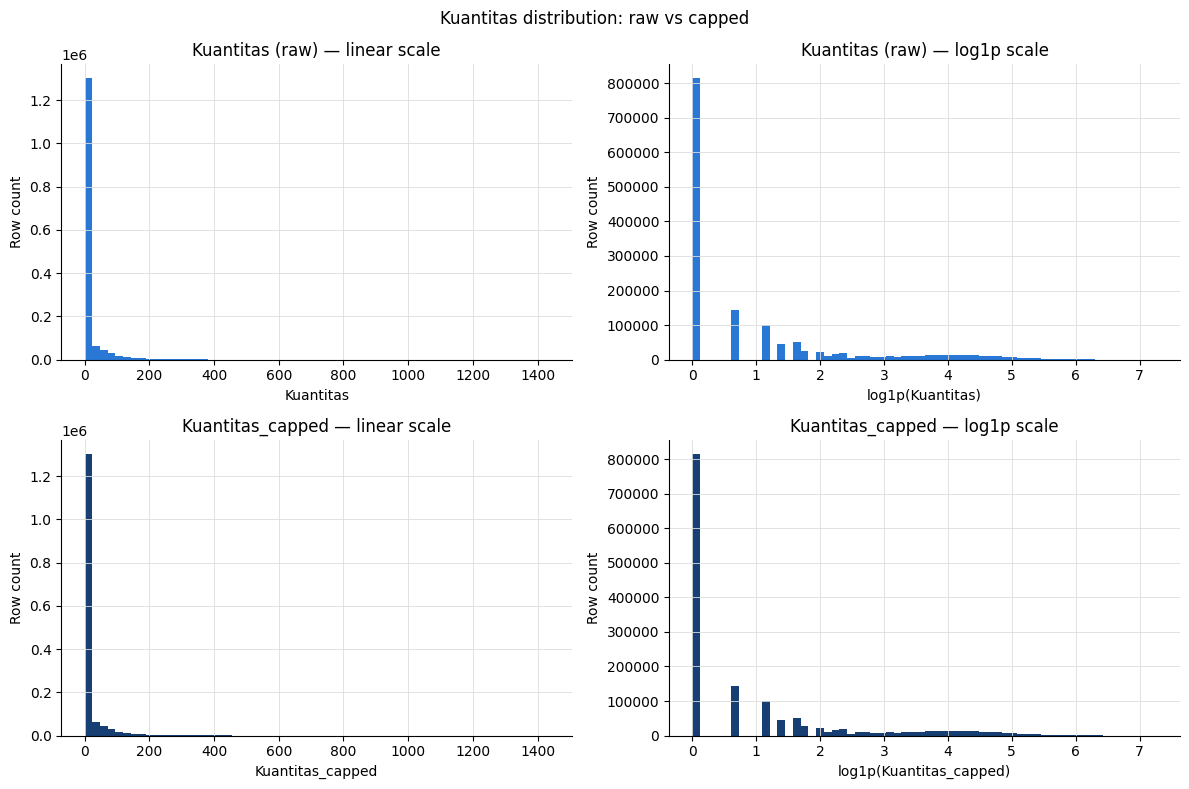

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(featured["Kuantitas"], bins=60, color=BLUE)
axes[0, 0].set_title("Kuantitas (raw) — linear scale")
axes[0, 0].set_xlabel("Kuantitas")
axes[0, 0].set_ylabel("Row count")

axes[0, 1].hist(np.log1p(featured["Kuantitas"]), bins=60, color=BLUE)
axes[0, 1].set_title("Kuantitas (raw) — log1p scale")
axes[0, 1].set_xlabel("log1p(Kuantitas)")
axes[0, 1].set_ylabel("Row count")

axes[1, 0].hist(featured["Kuantitas_capped"], bins=60, color=BLUE_DARK)
axes[1, 0].set_title("Kuantitas_capped — linear scale")
axes[1, 0].set_xlabel("Kuantitas_capped")
axes[1, 0].set_ylabel("Row count")

axes[1, 1].hist(np.log1p(featured["Kuantitas_capped"]), bins=60, color=BLUE_DARK)
axes[1, 1].set_title("Kuantitas_capped — log1p scale")
axes[1, 1].set_xlabel("log1p(Kuantitas_capped)")
axes[1, 1].set_ylabel("Row count")

fig.suptitle("Kuantitas distribution: raw vs capped")
plt.tight_layout()
plt.show()

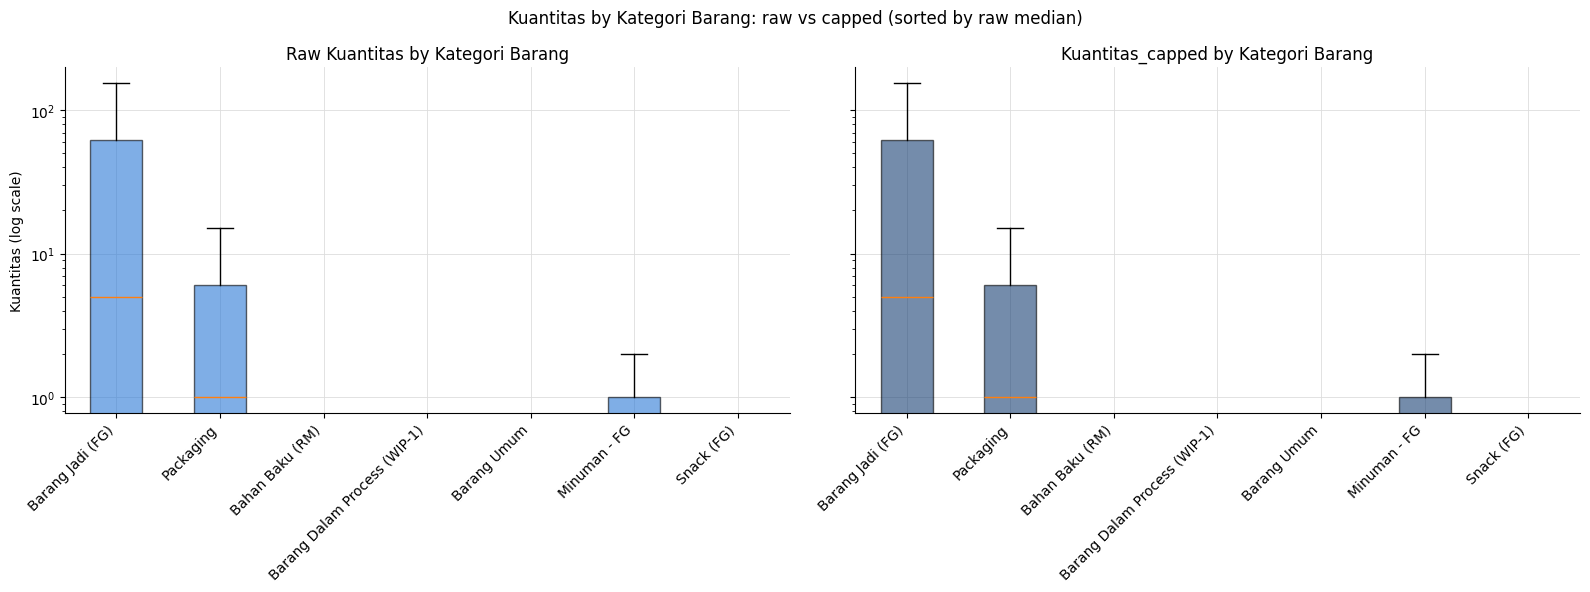

In [29]:
order = (
    featured.groupby("Kategori Barang", observed=True)["Kuantitas"]
    .median()
    .sort_values(ascending=False)
    .index
)
raw_by_cat = [featured.loc[featured["Kategori Barang"] == cat, "Kuantitas"] for cat in order]
capped_by_cat = [featured.loc[featured["Kategori Barang"] == cat, "Kuantitas_capped"] for cat in order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

box_raw = axes[0].boxplot(raw_by_cat, tick_labels=list(order), patch_artist=True, showfliers=False)
for patch in box_raw["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.6)
axes[0].set_yscale("log")
axes[0].set_ylabel("Kuantitas (log scale)")
axes[0].set_title("Raw Kuantitas by Kategori Barang")
for label in axes[0].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

box_capped = axes[1].boxplot(capped_by_cat, tick_labels=list(order), patch_artist=True, showfliers=False)
for patch in box_capped["boxes"]:
    patch.set_facecolor(BLUE_DARK)
    patch.set_alpha(0.6)
axes[1].set_title("Kuantitas_capped by Kategori Barang")
for label in axes[1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

fig.suptitle("Kuantitas by Kategori Barang: raw vs capped (sorted by raw median)")
plt.tight_layout()
plt.show()

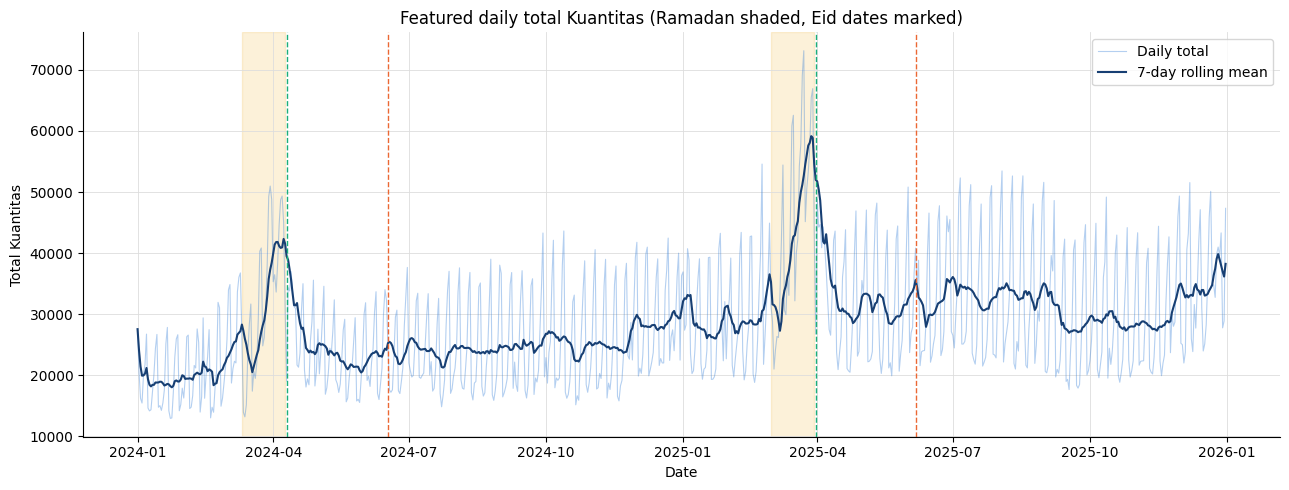

In [30]:
daily_total = featured.groupby("Tanggal")["Kuantitas"].sum()
rolling_mean = daily_total.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_total.index, daily_total.values, color=BLUE, alpha=0.35, linewidth=0.8, label="Daily total")
ax.plot(rolling_mean.index, rolling_mean.values, color=BLUE_DARK, linewidth=1.5, label="7-day rolling mean")

for _, (start, end) in RAMADAN_PERIODS.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#eda100", alpha=0.15)

for _, eid_date in EID_AL_FITR_DATES.items():
    ax.axvline(pd.Timestamp(eid_date), color="#1baf7a", linestyle="--", linewidth=1)

for _, eid_date in EID_AL_ADHA_DATES.items():
    ax.axvline(pd.Timestamp(eid_date), color="#eb6834", linestyle="--", linewidth=1)

ax.set_title("Featured daily total Kuantitas (Ramadan shaded, Eid dates marked)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Kuantitas")
ax.legend()
plt.tight_layout()
plt.show()

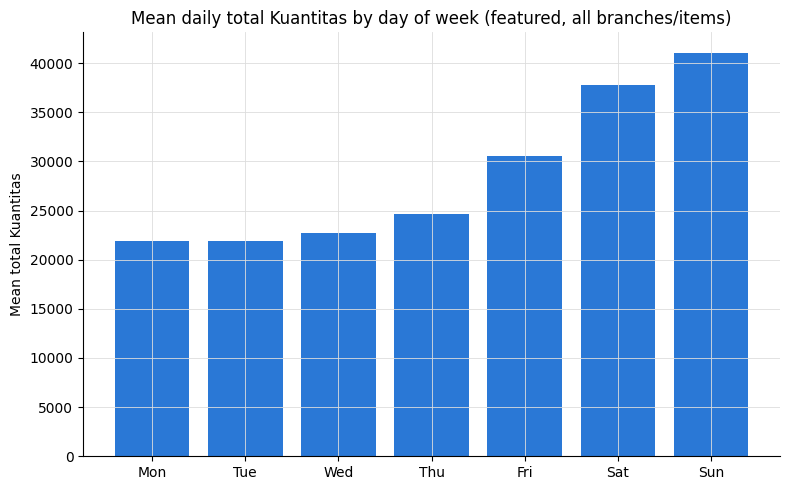

In [31]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

dow_daily_total = featured.groupby(["Tanggal", "day_of_week"])["Kuantitas"].sum().reset_index()
dow_mean = dow_daily_total.groupby("day_of_week")["Kuantitas"].mean().reindex(range(7))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(dow_labels, dow_mean.values, color=BLUE)
ax.set_title("Mean daily total Kuantitas by day of week (featured, all branches/items)")
ax.set_ylabel("Mean total Kuantitas")
plt.tight_layout()
plt.show()

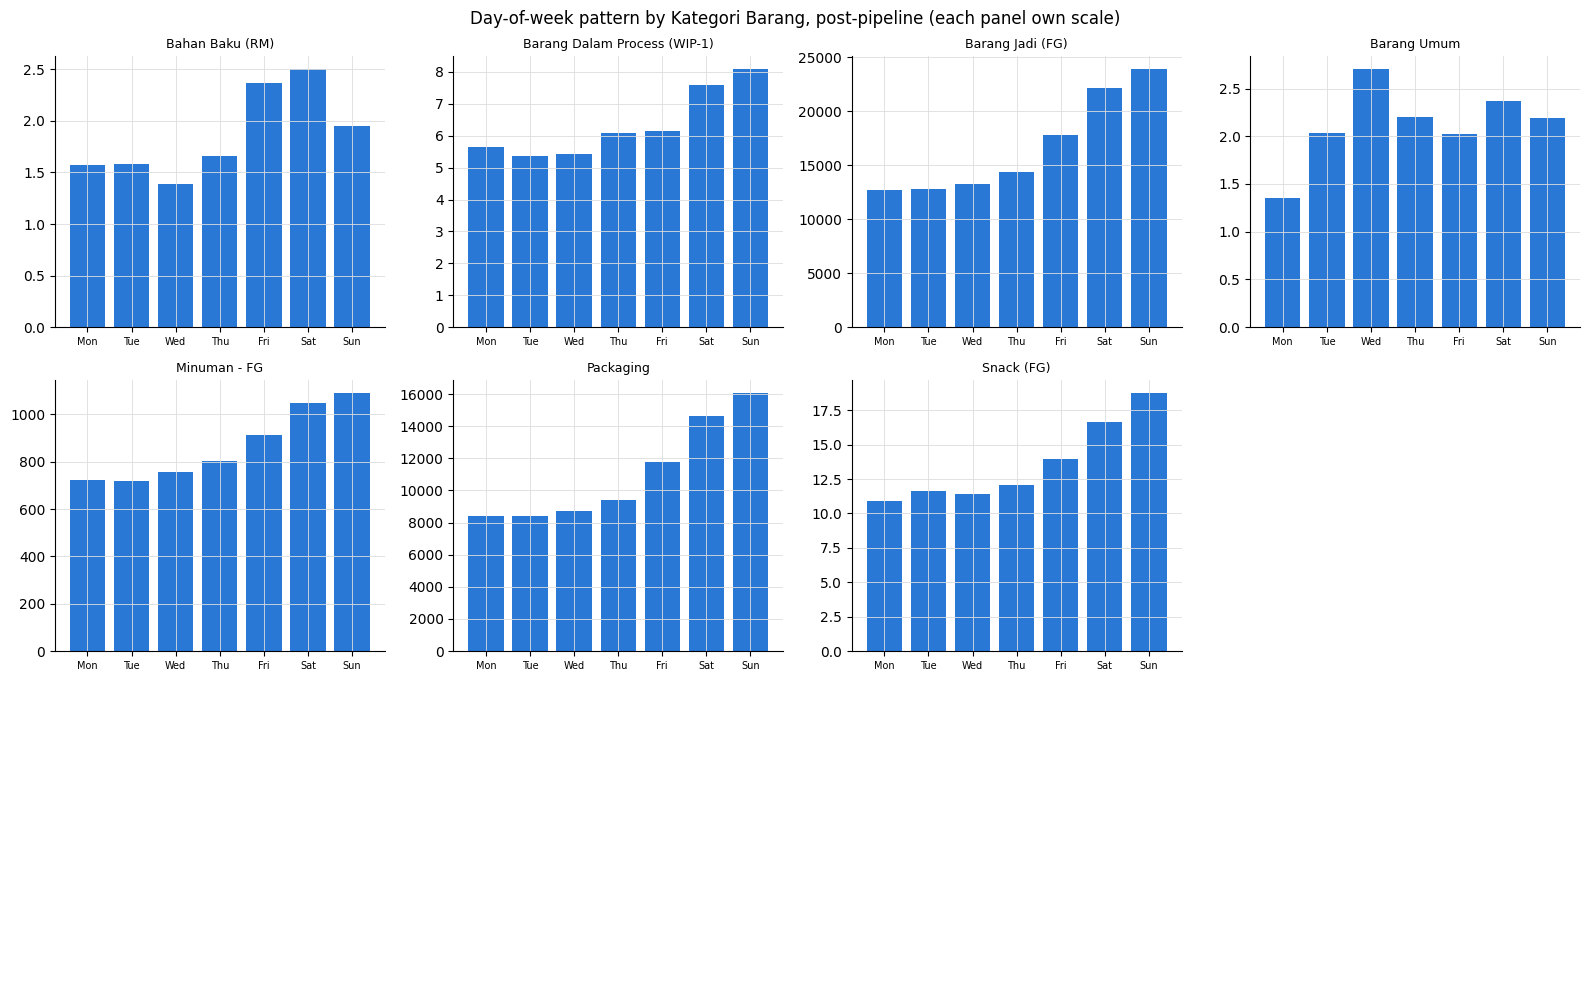

In [32]:
categories = sorted(str(c) for c in featured["Kategori Barang"].unique())

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = featured[featured["Kategori Barang"] == cat]
    sub_daily = sub.groupby(["Tanggal", "day_of_week"])["Kuantitas"].sum().reset_index()
    sub_dow_mean = sub_daily.groupby("day_of_week")["Kuantitas"].mean().reindex(range(7)).fillna(0)
    axes[i].bar(dow_labels, sub_dow_mean.values, color=BLUE)
    axes[i].set_title(cat, fontsize=9)
    axes[i].tick_params(axis="x", labelsize=7)

for j in range(len(categories), len(axes)):
    axes[j].axis("off")

fig.suptitle("Day-of-week pattern by Kategori Barang, post-pipeline (each panel own scale)")
plt.tight_layout()
plt.show()

## 27. Export featured.parquet

In [33]:
def export_featured(df: pd.DataFrame, output_dir: str = MODEL_READY_DIR) -> None:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    df.to_parquet(out / "featured.parquet", index=False)

In [34]:
export_featured(featured, MODEL_READY_DIR)
print(f"Wrote featured.parquet ({len(featured):,} rows) to {MODEL_READY_DIR}")

Wrote featured.parquet (1,502,522 rows) to /Users/ramapdp/Project/Personal/forecast-scm/dataset/model_ready


## 28. *(Opsional)* Cek sinkron dengan `utils/`

In [35]:
import inspect
import sys

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from utils.data_preprocessing import build_panel as _ref_panel
from utils.data_preprocessing import calendar_features as _ref_cal
from utils.data_preprocessing import normalize_items as _ref_norm
from utils.data_preprocessing import outlet_features as _ref_outlet
from utils.data_preprocessing import outlier_handling as _ref_outlier
from utils.data_preprocessing import prepare_forecast_data as _ref_prep

_MODUL_REF = [_ref_norm, _ref_panel, _ref_cal, _ref_outlet, _ref_outlier, _ref_prep]
_QUALIFIER = re.compile(
    r"\b(normalize_items|build_panel|calendar_features|outlet_features"
    r"|outlier_handling|prepare_forecast_data|merge_dataset|purging)\."
)
# Nama yang memang sengaja beda dari utils, jadi tidak dibandingkan.
_LEWATI = {"find_base_dir", "_MODUL_REF", "_QUALIFIER", "_LEWATI", "_kode",
           "_rujukan", "_nilai_sama", "BASE_DIR", "MODEL_READY_DIR", "RAW_DATA_FILE", "OUTLETS_FILE",
           "OVERRIDES_FILE", "REGION_MAPPING_FILE", "CLOSURES_FILE"}


def _kode(fn) -> str:
    """Kode sumber fungsi tanpa qualifier modul — di notebook semua fungsi satu namespace."""
    return _QUALIFIER.sub("", inspect.getsource(fn))


def _rujukan(nama):
    """Objek bernama `nama` di modul utils mana pun; None kalau namanya bukan milik utils."""
    for modul in _MODUL_REF:
        if hasattr(modul, nama):
            return getattr(modul, nama)
    return None


def _nilai_sama(a, b) -> bool:
    """re.Pattern tidak punya __eq__ yang berguna, jadi dibandingkan pola dan flag-nya."""
    if isinstance(a, re.Pattern) and isinstance(b, re.Pattern):
        return (a.pattern, a.flags) == (b.pattern, b.flags)
    try:
        return bool(a == b)
    except (ValueError, TypeError):
        return False


beda, n_fungsi, n_konstanta = [], 0, 0
for nama, obj in sorted(globals().items()):
    if nama in _LEWATI or nama.startswith("__"):
        continue
    ref = _rujukan(nama)
    if ref is None:
        continue
    if inspect.isfunction(obj):
        n_fungsi += 1
        if _kode(obj) != _kode(ref):
            beda.append(nama)
    elif nama.isupper() or nama.startswith("_"):
        n_konstanta += 1
        if not _nilai_sama(obj, ref):
            beda.append(nama)

if beda:
    print("BERBEDA dari utils/ — salin ulang atau samakan: " + ", ".join(beda))
else:
    print(f"Sinkron: {n_fungsi} fungsi + {n_konstanta} konstanta identik dengan utils/data_preprocessing/")

Sinkron: 73 fungsi + 39 konstanta identik dengan utils/data_preprocessing/
